# LLM-related CVE dynamics, 2022 – mid-2026

A reproducible analysis of LLM-related vulnerabilities in NVD, mapped to the
**OWASP Top 10 for LLM Applications (2025)** and cross-referenced with major
model releases.

**Pipeline:**
1. Sparse-clone the [fkie-cad/nvd-json-data-feeds](https://github.com/fkie-cad/nvd-json-data-feeds) mirror (CVE-2022 → CVE-2026).
2. Apply a two-tier filter (LLM-specific tooling + AI supply chain) with a deny-list to suppress false positives.
3. Map each CVE to OWASP LLM 2025 categories using description keywords + CWE classes.
4. Build time-series views over OWASP categories and CVSS, with model-release overlays.

Total runtime on free Colab: ~10–15 minutes (the clone is the slow part — about 1 GB).

## Setup

In [1]:
# Making sure packages are installed
!pip install -q pandas matplotlib seaborn

In [ ]:
import os, json, re, csv
from pathlib import Path
from collections import defaultdict, Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 140,
    "font.size": 10,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Resolve WORKDIR robustly. Previously this was `Path.cwd() / "llm_cve_analysis"`
# followed by os.chdir(WORKDIR) — which descended one level deeper on EVERY
# re-run (llm_cve_analysis/llm_cve_analysis/...). We now anchor to the repo root
# by locating the notebook, so re-running is idempotent and self-healing even if
# the kernel is already parked inside a nested workdir.
if Path("/content").exists():
    WORKDIR = Path("/content/llm_cve_analysis")            # Colab
else:
    _start = Path.cwd()
    _repo = next((p for p in (_start, *_start.parents)
                  if (p / "llm_cve_dynamics.ipynb").exists()), None)
    if _repo is None:                                      # not under the repo tree
        _repo = _start.parent if _start.name == "llm_cve_analysis" else _start
    WORKDIR = _repo / "llm_cve_analysis"
WORKDIR.mkdir(exist_ok=True, parents=True)
os.chdir(WORKDIR)
print("Working directory:", WORKDIR)

## Sparse-clone the NVD JSON mirror (CVE-2022 → CVE-2026)

We use `git sparse-checkout` to fetch only the years we care about, which keeps the
download to ~1.1 GB instead of ~9 GB for the full history.

In [ ]:
NVD = WORKDIR / "nvd"
if not NVD.exists():
    !git clone --filter=blob:none --no-checkout --depth 1 https://github.com/fkie-cad/nvd-json-data-feeds.git nvd
    %cd $NVD
    !git sparse-checkout init --cone
    !git sparse-checkout set CVE-2022 CVE-2023 CVE-2024 CVE-2025 CVE-2026
    !git checkout
    %cd $WORKDIR
else:
    print("NVD already cloned.")
!du -sh $NVD/CVE-* 2>/dev/null | tail -10

## Filter rules

**Two relevance tiers** (a CVE that matches neither is dropped):

- **Tier 1 — `adversarial`:** explicit LLM/GenAI lexicon — model families with
  disambiguators (e.g. `\bclaude (3|3\.5|sonnet|opus)\b`, not bare `claude`),
  prompt-injection / jailbreak / RAG / system-prompt-leak terms, and ~50 LLM-specific
  tools (LangChain, vLLM, Ollama, Open WebUI, ChromaDB, …).
- **Tier 2 — `supply_chain`:** classical ML / DS frameworks (TensorFlow, PyTorch,
  ONNX, scikit-learn, XGBoost, …), but only when an ML-context word is also present.

A short **deny-list** suppresses common-noun collisions: `crowdstrike falcon`,
`resi gemini-net`, etc.

In [4]:
TIER_1_PATTERNS = [
    r"\blarge language model", r"\bllms?\b", r"\bgenerative ai\b", r"\bgenai\b",
    r"\bchatgpt\b", r"\bopenai\b", r"\banthropic\b",
    r"\bllama[\s-]?(2|3|4|cpp|index|file)", r"\bllama[- ]?guard\b",
    r"\bgpt-?(3\.5|4|4o|5)",
    r"\b(google )?gemini (1|1\.5|2|pro|flash|ultra|nano|model|ai|llm)",
    r"\banthropic claude\b", r"\bclaude (3|3\.5|haiku|sonnet|opus|instant|2|1)",
    r"\bmistral (7b|small|medium|large|nemo)", r"\bmixtral\b",
    r"\bqwen ?\d", r"\bdeepseek\b", r"\bgrok\b", r"\bcohere (command|embed)",
    r"\bprompt injection\b", r"\bjailbreak(ing)?\b",
    r"\bsystem prompt (leak|disclosure|injection)", r"\bprompt leakage\b",
    r"\brag (system|pipeline|application)", r"\bretrieval[- ]augmented\b",
    r"\bhallucinat", r"\bfine[- ]?tun", r"\bhugging\s?face\b", r"\btransformer model",
    r"\blangchain\b", r"\bllamaindex\b", r"\bllama[- ]index\b",
    r"\bvllm\b", r"\bollama\b", r"\bbentoml\b", r"\btriton inference\b",
    r"\bmlflow\b", r"\bkubeflow\b", r"\bautogpt\b",
    r"\bgradio\b", r"\btext[- ]generation[- ]webui\b",
    r"\bvector (db|database|store)\b", r"\bembedding model\b",
    r"\bopen[- ]?webui\b", r"\bcomfyui\b", r"\binvoke[- ]?ai\b",
    r"\banything[- ]?llm\b", r"\bflowise\b", r"\bdify\b",
    r"\bhaystack\b.*\b(llm|ai|nlp)", r"\bnvidia nemo\b", r"\bguardrails (ai|llm)",
    r"\bllamafile\b", r"\btext-generation-inference\b", r"\bopenai[- ]?api\b",
    r"\binference server\b",
    r"\bchromadb\b", r"\bpinecone\b", r"\bweaviate\b", r"\bmilvus\b",
    r"\bqdrant\b", r"\bfaiss\b",
    r"\blunary\b", r"\bgiskard\b", r"\bvanna\b", r"\binstructlab\b",
    r"\bnemo[- ]guardrails\b", r"\bsafetensors\b", r"\bpickle.*model\b",
    r"\bdspy\b", r"\blitellm\b", r"\bcrewai\b",
    r"\bautogen\b.*\b(ai|llm|model)", r"\bmem ?gpt\b",
    r"\bopen[- ]assistant\b", r"\bjan[- ]ai\b", r"\blm studio\b", r"\bkoboldcpp\b",
]
T1 = re.compile("|".join(TIER_1_PATTERNS), re.I)

TIER_2_FRAMEWORKS = [
    r"\bpytorch\b", r"\btensorflow\b", r"\bkeras\b", r"\bscikit[- ]learn\b",
    r"\bonnx\b", r"\btransformers\b", r"\bdatasets\b",
    r"\bxgboost\b", r"\blightgbm\b", r"\bopenvino\b", r"\bmlx\b",
]
T2 = re.compile("|".join(TIER_2_FRAMEWORKS), re.I)
T2_CONTEXT = re.compile(
    r"\b(model|\bai\b|ml\b|machine learning|deep learning|neural network|"
    r"inference|training|llm|nlp|tensor)\b", re.I)

DENY_PRODUCTS = [
    r"resi[- ]gemini", r"gemini[- ]net",
    r"crowdstrike falcon", r"falcon logscale", r"falconpro",
    r"\bphi[- ]node\b",
]
DENY_RX = re.compile("|".join(DENY_PRODUCTS), re.I)


def classify_relevance(text: str) -> str:
    if DENY_RX.search(text): return ""
    if T1.search(text):       return "adversarial"
    if T2.search(text) and T2_CONTEXT.search(text): return "supply_chain"
    return ""

## OWASP Top 10 LLM (2025) mapping

Each kept CVE is matched against keyword patterns **and** CWE class sets per category.
A single CVE can map to multiple categories. `supply_chain`-tier CVEs with no other
hit default to LLM03.

The CWE sets capture the way real CVE analysts assign:
- **LLM02** ↔ CWE-200/209/532/538/540/359/201 (info-disclosure family)
- **LLM03** ↔ CWE-502/94/78/829/915/1188/1395 (deserialization, code-injection, malicious-package)
- **LLM05** ↔ CWE-79/80/918/601 (XSS / SSRF / open-redirect — typical when LLM output is rendered)
- **LLM06** ↔ CWE-269/732/285 (authorization-bypass on tool-call surfaces)
- **LLM10** ↔ CWE-400/770/674/789/834/835 (resource exhaustion)

LLM01, LLM04, LLM07, LLM09 intentionally have no CWE component — they describe
behaviors that the CWE taxonomy doesn't directly model.

In [5]:
OWASP_LLM = {
    "LLM01_Prompt_Injection": (
        r"prompt injection|prompt[- ]inject|jailbreak|indirect (prompt|injection)|instruction injection",
        set(),
    ),
    "LLM02_Sensitive_Info_Disclosure": (
        r"information disclosure|data leak|sensitive (data|information)|\bpii\b|credential (leak|exposure)|secret leak|training data (leak|extraction)|membership inference",
        {"CWE-200", "CWE-209", "CWE-532", "CWE-538", "CWE-540", "CWE-359", "CWE-201"},
    ),
    "LLM03_Supply_Chain": (
        r"supply[- ]chain|malicious (model|package|dependency)|pickle (deserializ|injection)|safetensors|deserializ|model file|backdoor.*model|trojan.*model",
        {"CWE-502", "CWE-94", "CWE-78", "CWE-829", "CWE-915", "CWE-1188", "CWE-1395"},
    ),
    "LLM04_Data_Model_Poisoning": (
        r"data poison|model poison|training data poison|backdoor (attack|in.*model)|fine[- ]?tun.*malic|adversarial (training|example)",
        set(),
    ),
    "LLM05_Improper_Output_Handling": (
        r"output handling|insecure output|unsanitized output|render(ed)? (markdown|html).*model",
        {"CWE-79", "CWE-80", "CWE-918", "CWE-601"},
    ),
    "LLM06_Excessive_Agency": (
        r"excessive (agency|permissions|functionality)|agent.*unauthorized|tool (use|call).*unauthor|function call.*injection|plugin.*unauthor",
        {"CWE-269", "CWE-732", "CWE-285"},
    ),
    "LLM07_System_Prompt_Leakage": (
        r"system prompt (leak|disclosure|exposure|extract)|prompt leakage",
        set(),
    ),
    "LLM08_Vector_Embedding_Weakness": (
        r"vector (db|database|store)|embedding.*(poison|leak|inject)|\brag\b.*(poison|attack|inject)|chroma(db)?|pinecone|weaviate|milvus|qdrant|faiss",
        set(),
    ),
    "LLM09_Misinformation": (
        r"hallucinat|misinformation|package hallucinat",
        set(),
    ),
    "LLM10_Unbounded_Consumption": (
        r"denial of service|\bdos\b|resource exhaustion|unbounded (consum|generation)|infinite loop.*model|token.*flood|context.*overflow",
        {"CWE-400", "CWE-770", "CWE-674", "CWE-789", "CWE-834", "CWE-835"},
    ),
}

OWASP_KW  = {k: re.compile(p, re.I) for k, (p, _) in OWASP_LLM.items()}
OWASP_CWE = {k: cwes for k, (_, cwes) in OWASP_LLM.items()}

def categorize_owasp(text: str, cwes: list, relevance: str) -> list:
    cwes_set = set(cwes)
    hits = set()
    for cat in OWASP_LLM:
        if OWASP_KW[cat].search(text):     hits.add(cat)
        if cwes_set & OWASP_CWE[cat]:      hits.add(cat)
    if relevance == "supply_chain" and not hits:
        hits.add("LLM03_Supply_Chain")
    return sorted(hits)

## Walk the NVD tree and build the filtered dataset

This scans ~160k CVEs and keeps the ~1,500 LLM-relevant ones. Takes 1–3 minutes on Colab.

In [6]:
records = []
non_records = []          # counterfactual: CVEs that fail the LLM relevance filter
counters = defaultdict(int)

for year_dir in sorted(NVD.glob("CVE-2*")):
    year = year_dir.name
    for f in year_dir.rglob("*.json"):
        counters[f"{year}_scanned"] += 1
        try:
            cve = json.loads(f.read_text())
        except Exception:
            continue

        desc_blocks = cve.get("descriptions", [])
        desc = next((d["value"] for d in desc_blocks if d.get("lang") == "en"), "")
        if not desc:
            continue

        cpe_texts = []
        for cfg in cve.get("configurations", []):
            for node in cfg.get("nodes", []):
                for m in node.get("cpeMatch", []):
                    cpe_texts.append(m.get("criteria", ""))
        cpe_blob = " ".join(cpe_texts)

        # CVSS extraction runs for EVERY CVE (needed for the counterfactual set too)
        metrics = cve.get("metrics", {})
        cvss_score = cvss_severity = cvss_vector = cvss_version = None
        for key, ver in [("cvssMetricV31", "3.1"), ("cvssMetricV30", "3.0"), ("cvssMetricV2", "2.0")]:
            if key in metrics and metrics[key]:
                m = metrics[key][0]; cd = m.get("cvssData", {})
                cvss_score    = cd.get("baseScore")
                cvss_severity = cd.get("baseSeverity") or m.get("baseSeverity")
                cvss_vector   = cd.get("vectorString")
                cvss_version  = ver
                break

        combined = f"{desc} {cpe_blob}"
        rel = classify_relevance(combined)
        if not rel:
            # Counterfactual baseline: keep a lightweight record (no description/CPE)
            non_records.append({
                "cve_id":        cve.get("id"),
                "published":     cve.get("published"),
                "relevance":     "none",
                "cvss_score":    cvss_score,
                "cvss_severity": cvss_severity,
                "cvss_version":  cvss_version,
            })
            counters[f"{year}_none"] += 1
            continue

        cwes = []
        for w in cve.get("weaknesses", []):
            for d in w.get("description", []):
                v = d.get("value")
                if v and v.startswith("CWE-"): cwes.append(v)

        owasp_cats = categorize_owasp(combined, cwes, rel)

        records.append({
            "cve_id": cve.get("id"),
            "published": cve.get("published"),
            "last_modified": cve.get("lastModified"),
            "description": desc,
            "cpe_blob": cpe_blob[:400],
            "relevance": rel,
            "cvss_score": cvss_score,
            "cvss_severity": cvss_severity,
            "cvss_version": cvss_version,
            "cvss_vector": cvss_vector,
            "cwes": "|".join(sorted(set(cwes))),
            "owasp_cats": "|".join(owasp_cats),
        })
        counters[f"{year}_kept"] += 1
    print(f"{year}: scanned={counters[f'{year}_scanned']:>6}  "
          f"kept={counters[f'{year}_kept']:>5}  none={counters[f'{year}_none']:>6}")

df = pd.DataFrame(records)
df.to_csv("llm_cves.csv", index=False)

# Counterfactual (non-LLM) set — saved to the gitignored WORKDIR, not the repo root
df_non = pd.DataFrame(non_records)
df_non.to_csv(Path(WORKDIR) / "non_llm_cves.csv", index=False)
print(f"\nTotal LLM-relevant CVEs: {len(df)}  |  non-LLM (counterfactual) CVEs: {len(df_non)}")


CVE-2022: scanned= 27518  kept=  169  none= 27349
CVE-2023: scanned= 31213  kept=   98  none= 31115
CVE-2024: scanned= 39152  kept=  431  none= 38721
CVE-2025: scanned= 44853  kept=  439  none= 44414
CVE-2026: scanned= 28981  kept=  630  none= 28351

Total LLM-relevant CVEs: 1767  |  non-LLM (counterfactual) CVEs: 169950


## Tidy the data and define the model-release timeline

In [7]:
df["published"] = pd.to_datetime(df["published"], errors="coerce")
df = df.dropna(subset=["published"]).copy()
df["cvss_score"] = pd.to_numeric(df["cvss_score"], errors="coerce")
df["year"]      = df["published"].dt.year
df["quarter"]   = df["published"].dt.to_period("Q").dt.to_timestamp()
df["month"]     = df["published"].dt.to_period("M").dt.to_timestamp()

# Explode multi-category mappings
df["owasp_list"] = df["owasp_cats"].fillna("").str.split("|")
exp = df.explode("owasp_list").rename(columns={"owasp_list": "owasp"})
exp = exp[exp["owasp"].astype(str).str.startswith("LLM")]

# Cap at end of April 2026 (data is partial after)
CUT      = pd.Timestamp("2026-04-30")
df_full  = df[df["published"] <= CUT].copy()
exp_full = exp[exp["published"] <= CUT].copy()

RELEASES = [
    ("ChatGPT",           "2022-11-30", "OpenAI"),
    ("GPT-4",             "2023-03-14", "OpenAI"),
    ("LLaMA",             "2023-02-24", "Meta"),
    ("LLaMA 2",           "2023-07-18", "Meta"),
    ("Claude 2",          "2023-07-11", "Anthropic"),
    ("Mistral 7B",        "2023-09-27", "Mistral"),
    ("Gemini 1.0",        "2023-12-06", "Google"),
    ("Claude 3",          "2024-03-04", "Anthropic"),
    ("LLaMA 3",           "2024-04-18", "Meta"),
    ("GPT-4o",            "2024-05-13", "OpenAI"),
    ("Claude 3.5 Sonnet", "2024-06-20", "Anthropic"),
    ("o1",                "2024-09-12", "OpenAI"),
    ("DeepSeek-R1",       "2025-01-20", "DeepSeek"),
    ("Claude 3.7 Sonnet", "2025-02-24", "Anthropic"),
    ("GPT-4.5",           "2025-02-27", "OpenAI"),
    ("LLaMA 4",           "2025-04-05", "Meta"),
    ("GPT-5",             "2025-08-07", "OpenAI"),
    ("GPT-5.2",           "2025-12-11", "OpenAI"),
]
rel_df = pd.DataFrame(RELEASES, columns=["model", "date", "vendor"])
rel_df["date"] = pd.to_datetime(rel_df["date"])

OWASP_ORDER = [
    "LLM01_Prompt_Injection", "LLM02_Sensitive_Info_Disclosure",
    "LLM03_Supply_Chain", "LLM04_Data_Model_Poisoning",
    "LLM05_Improper_Output_Handling", "LLM06_Excessive_Agency",
    "LLM07_System_Prompt_Leakage", "LLM08_Vector_Embedding_Weakness",
    "LLM09_Misinformation", "LLM10_Unbounded_Consumption",
]
OWASP_SHORT = {
    "LLM01_Prompt_Injection":          "LLM01 Prompt Injection",
    "LLM02_Sensitive_Info_Disclosure": "LLM02 Sensitive Info",
    "LLM03_Supply_Chain":              "LLM03 Supply Chain",
    "LLM04_Data_Model_Poisoning":      "LLM04 Data/Model Poisoning",
    "LLM05_Improper_Output_Handling":  "LLM05 Improper Output",
    "LLM06_Excessive_Agency":          "LLM06 Excessive Agency",
    "LLM07_System_Prompt_Leakage":     "LLM07 System Prompt Leak",
    "LLM08_Vector_Embedding_Weakness": "LLM08 Vector/Embedding",
    "LLM09_Misinformation":            "LLM09 Misinformation",
    "LLM10_Unbounded_Consumption":     "LLM10 Unbounded Consumption",
}
PALETTE = [
    "#4C72B0", "#55A868", "#8172B3", "#937860", "#DA8BC3",
    "#CCB974", "#64B5CD", "#E07B39", "#7F7F7F", "#C44E52",
]

# Summary
summary = pd.DataFrame({
    "n_cves":          df_full.groupby("year").size(),
    "n_adversarial":   df_full[df_full["relevance"]=="adversarial"].groupby("year").size(),
    "n_supply_chain":  df_full[df_full["relevance"]=="supply_chain"].groupby("year").size(),
    "mean_cvss":       df_full.dropna(subset=["cvss_score"]).groupby("year")["cvss_score"].mean().round(2),
    "median_cvss":     df_full.dropna(subset=["cvss_score"]).groupby("year")["cvss_score"].median(),
    "pct_high":  (df_full.dropna(subset=["cvss_score"])
                  .assign(hi=lambda d: d["cvss_score"] >= 7.0)
                  .groupby("year")["hi"].mean() * 100).round(1),
    "pct_crit":  (df_full.dropna(subset=["cvss_score"])
                  .assign(c=lambda d: d["cvss_score"] >= 9.0)
                  .groupby("year")["c"].mean() * 100).round(1),
}).fillna(0)
summary

,n_cves,n_adversarial,n_supply_chain,mean_cvss,median_cvss,pct_high,pct_crit
year,,,,,,,
2022,167,3,164,6.12,5.9,18.0,0.0
2023,93,66,27,7.72,7.5,77.4,25.8
2024,309,299,10,7.46,7.5,65.4,21.2
2025,498,483,15,7.35,7.5,65.1,17.6
2026,347,335,12,7.23,7.5,63.8,14.6


## Figure 1: monthly volume with model-release overlay

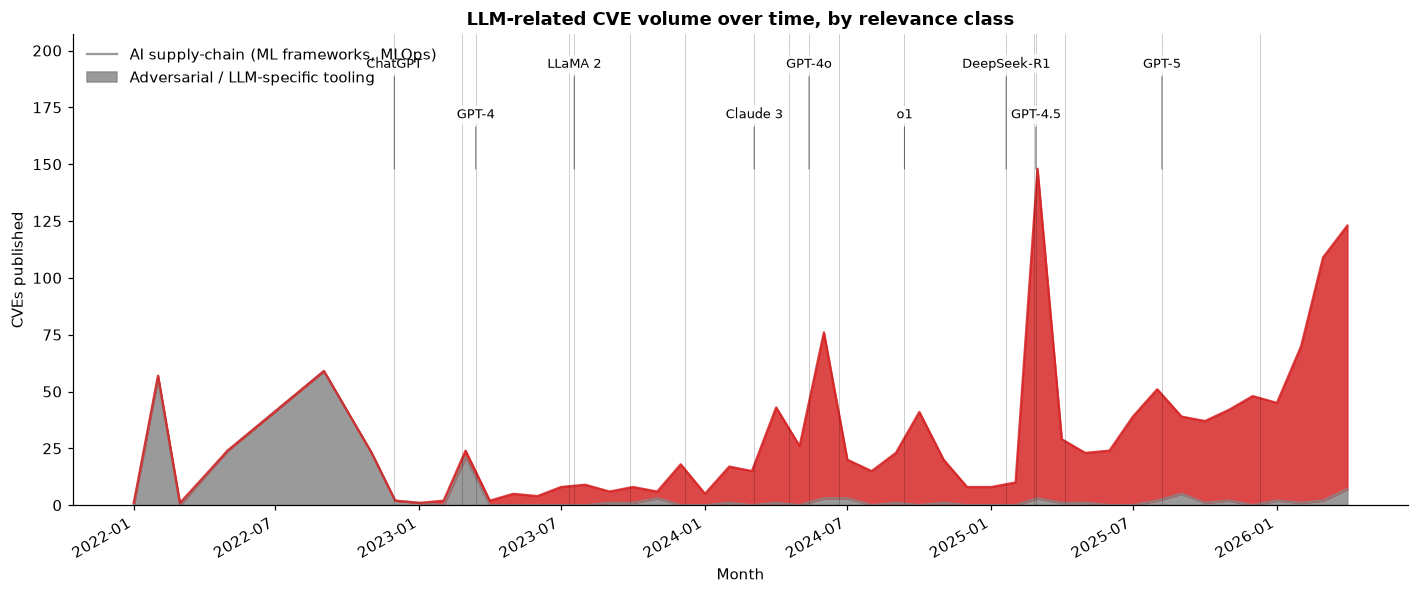

In [8]:
fig, ax = plt.subplots(figsize=(13, 5.5))
monthly = (df_full.groupby(["month","relevance"]).size()
           .unstack(fill_value=0)
           .reindex(columns=["supply_chain","adversarial"], fill_value=0))
monthly.plot(kind="area", ax=ax, stacked=True, alpha=0.85,
             color=["#888888", "#d62728"])
ax.set_ylabel("CVEs published"); ax.set_xlabel("Month")
ax.set_title("LLM-related CVE volume over time, by relevance class")
ax.legend(["AI supply-chain (ML frameworks, MLOps)",
           "Adversarial / LLM-specific tooling"], loc="upper left", frameon=False)

ymax = monthly.sum(axis=1).max()
for _, r in rel_df.iterrows():
    if r["date"] <= CUT:
        ax.axvline(r["date"], color="black", lw=0.5, alpha=0.25)

# Staggered labels to avoid collisions
ANNOTATE = [("ChatGPT",1.30), ("GPT-4",1.15), ("LLaMA 2",1.30),
            ("Claude 3",1.15), ("GPT-4o",1.30), ("o1",1.15),
            ("DeepSeek-R1",1.30), ("GPT-4.5",1.15), ("GPT-5",1.30)]
rel_by_name = {r["model"]: r for _, r in rel_df.iterrows()}
for name, ypos in ANNOTATE:
    r = rel_by_name.get(name)
    if r is None or r["date"] > CUT: continue
    ax.annotate(name,
        xy=(r["date"], ymax*0.99), xytext=(r["date"], ymax*ypos),
        ha="center", fontsize=8.5,
        arrowprops=dict(arrowstyle="-", color="black", lw=0.7, alpha=0.5),
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8))

ax.set_ylim(0, ymax*1.40)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout(); plt.show()

## Figures 2 & 3: OWASP composition over time

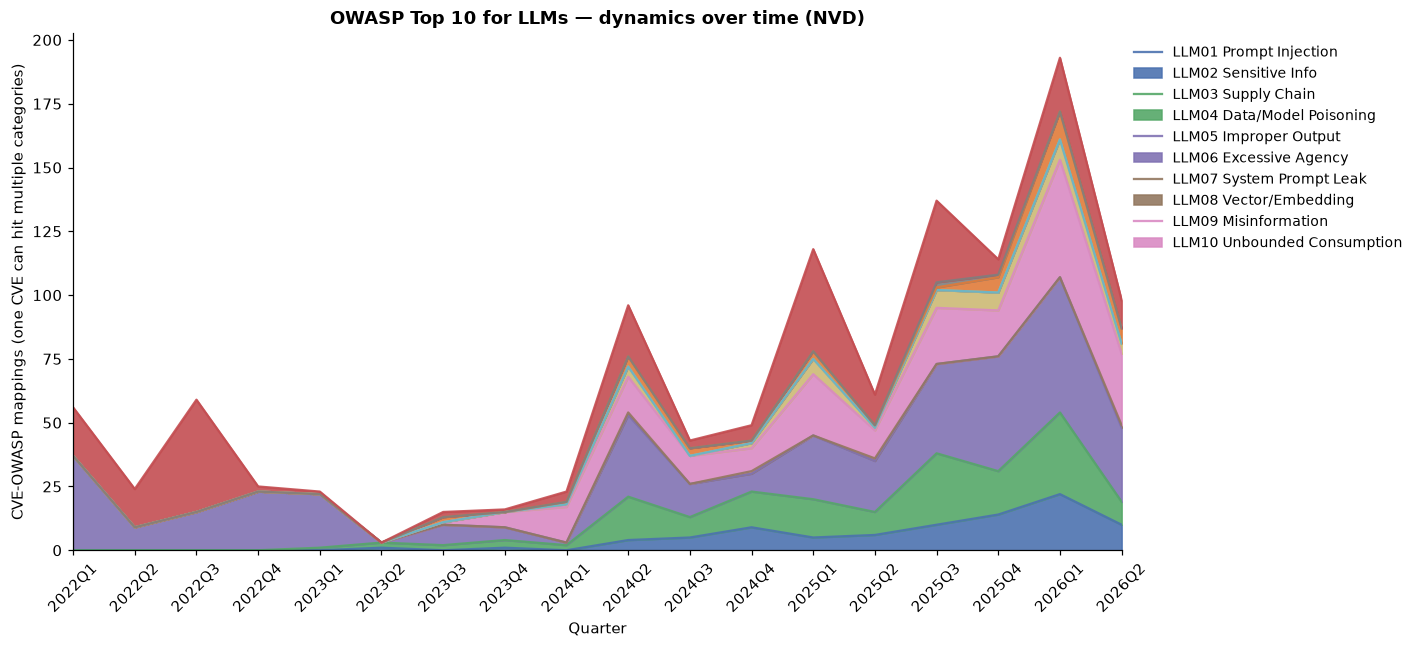

In [9]:
qcat = (exp_full.groupby(["quarter","owasp"]).size()
        .unstack(fill_value=0)
        .reindex(columns=OWASP_ORDER, fill_value=0))
qticks = pd.date_range("2022-01-01", "2026-04-01", freq="QS")
qlabels = [f"{d.year}Q{((d.month-1)//3)+1}" for d in qticks]

fig, ax = plt.subplots(figsize=(13, 6))
qcat.plot(kind="area", ax=ax, stacked=True, color=PALETTE, alpha=0.9)
ax.set_ylabel("CVE-OWASP mappings (one CVE can hit multiple categories)")
ax.set_xlabel("Quarter")
ax.set_title("OWASP Top 10 for LLMs — dynamics over time (NVD)")
ax.legend([OWASP_SHORT[c] for c in OWASP_ORDER],
          loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False, fontsize=9)
ax.set_xticks(qticks); ax.set_xticklabels(qlabels, rotation=45)
plt.tight_layout(); plt.show()

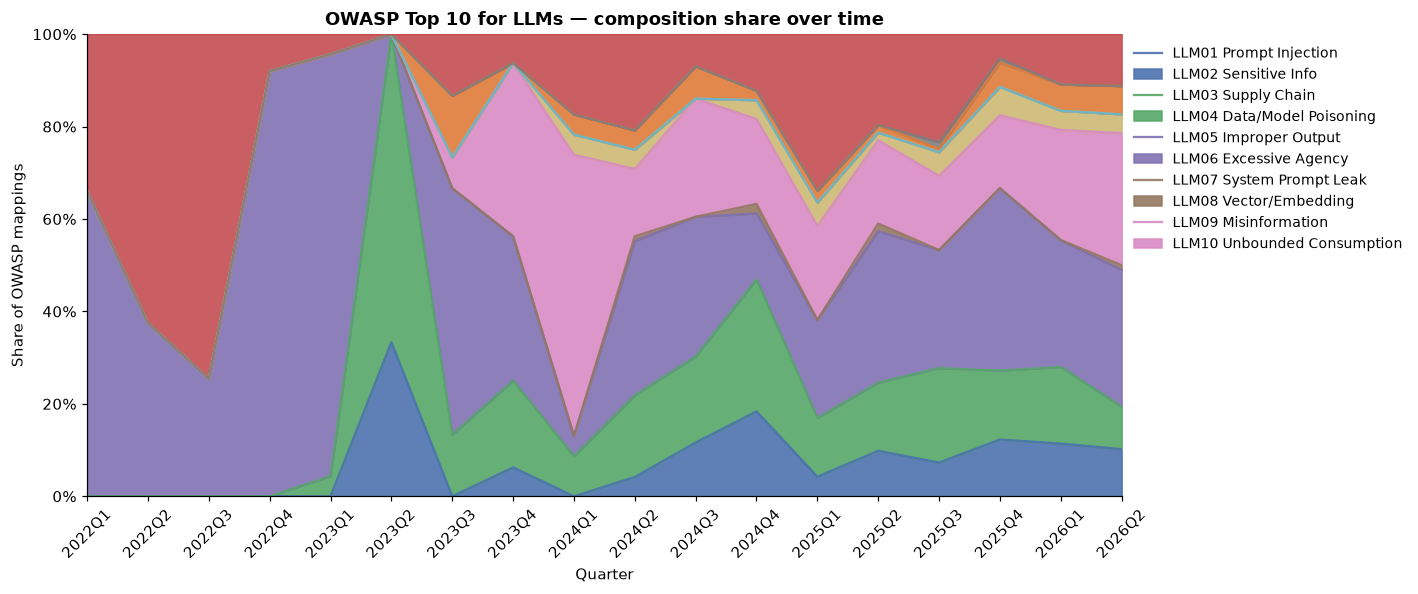

In [10]:
fig, ax = plt.subplots(figsize=(13, 5.5))
qshare = qcat.div(qcat.sum(axis=1), axis=0).fillna(0)
qshare.plot(kind="area", ax=ax, stacked=True, color=PALETTE, alpha=0.9)
ax.set_ylim(0, 1)
ax.set_ylabel("Share of OWASP mappings")
ax.set_xlabel("Quarter")
ax.set_title("OWASP Top 10 for LLMs — composition share over time")
ax.legend([OWASP_SHORT[c] for c in OWASP_ORDER],
          loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False, fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y*100)}%"))
ax.set_xticks(qticks); ax.set_xticklabels(qlabels, rotation=45)
plt.tight_layout(); plt.show()

## Figure 4: OWASP × quarter heatmap

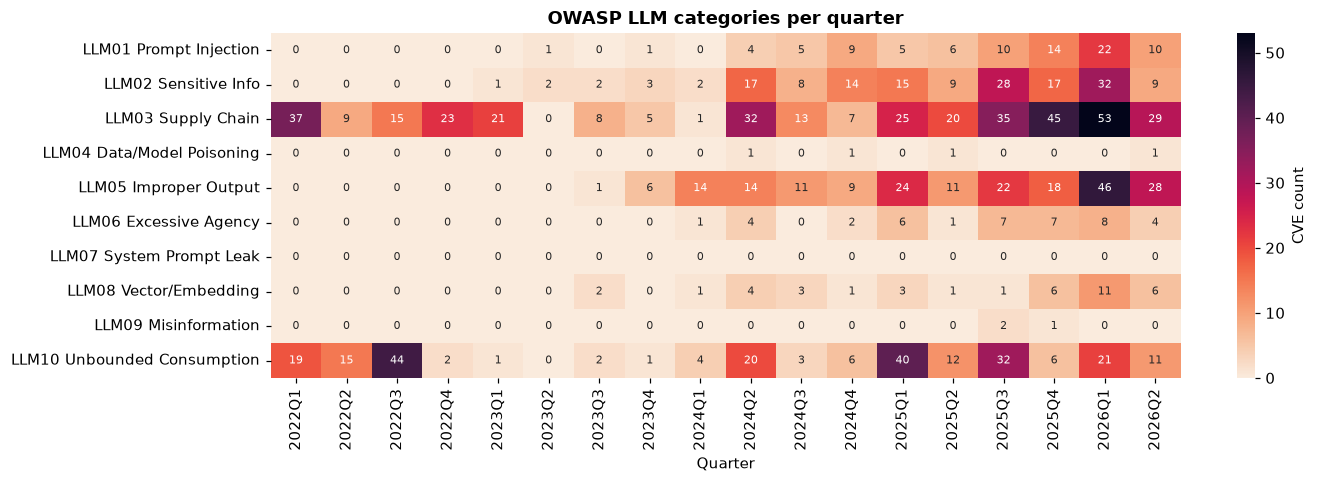

In [11]:
fig, ax = plt.subplots(figsize=(13, 4.5))
hm = qcat.T
hm.index = [OWASP_SHORT[c] for c in hm.index]
hm.columns = [f"{d.year}Q{((d.month-1)//3)+1}" for d in hm.columns]
sns.heatmap(hm, cmap="rocket_r", annot=True, fmt="d",
            cbar_kws={"label": "CVE count"}, ax=ax, annot_kws={"size": 7})
ax.set_xlabel("Quarter"); ax.set_ylabel("")
ax.set_title("OWASP LLM categories per quarter")
plt.tight_layout(); plt.show()

## Figure 5: CVSS distribution per quarter

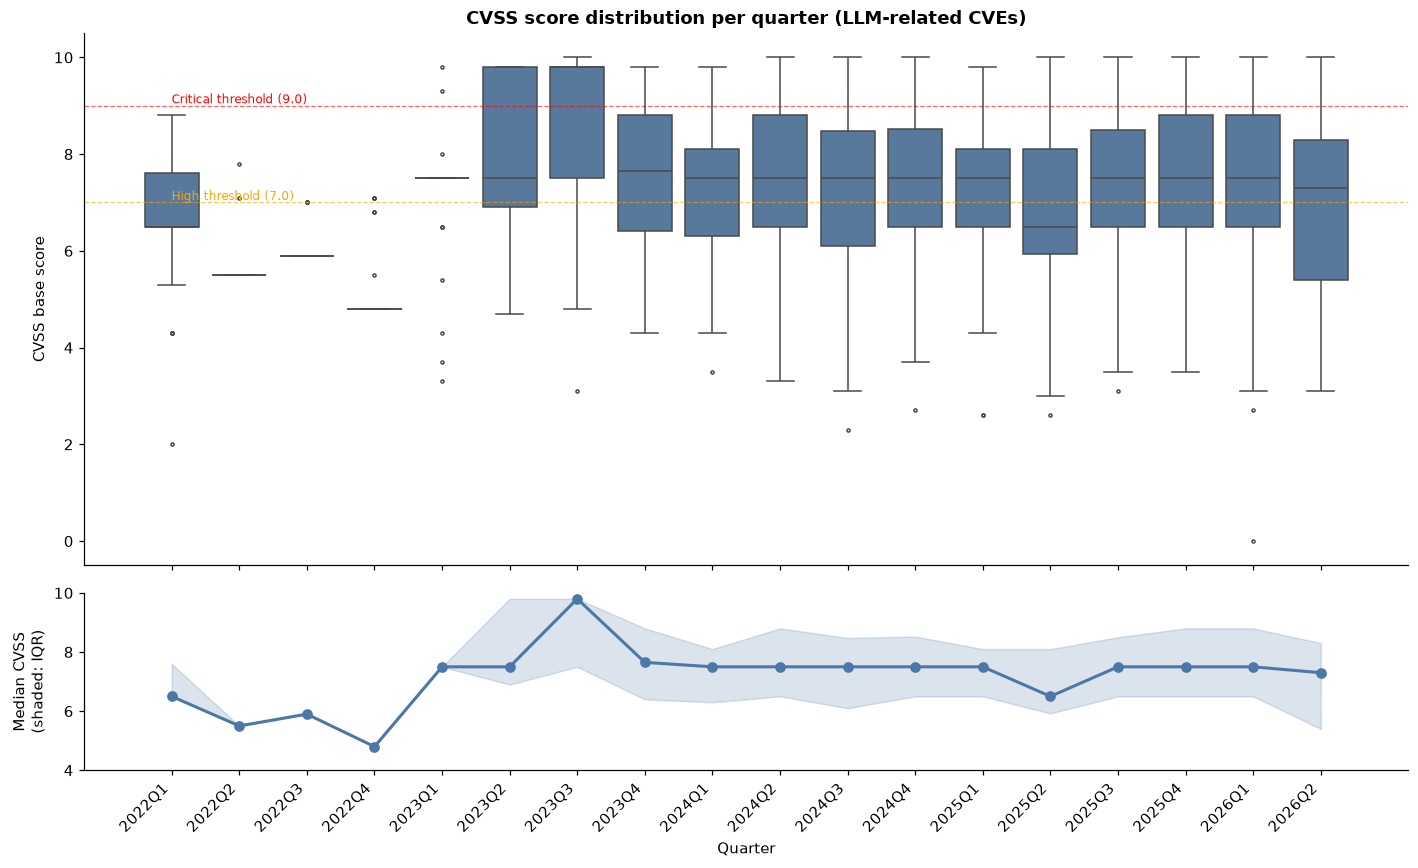

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

scored = df_full.dropna(subset=["cvss_score"]).copy()
scored["quarter_str"] = scored["quarter"].apply(lambda d: f"{d.year}Q{((d.month-1)//3)+1}")
order = sorted(scored["quarter_str"].unique(), key=lambda q: (int(q[:4]), int(q[-1])))

sns.boxplot(data=scored, x="quarter_str", y="cvss_score", order=order,
            color="#4c78a8", fliersize=2, ax=ax1)
ax1.set_ylabel("CVSS base score"); ax1.set_xlabel("")
ax1.set_title("CVSS score distribution per quarter (LLM-related CVEs)")
ax1.axhline(7.0, color="orange", lw=0.8, ls="--", alpha=0.6)
ax1.axhline(9.0, color="red",    lw=0.8, ls="--", alpha=0.6)
ax1.text(0, 7.05, "High threshold (7.0)",    color="orange", fontsize=8)
ax1.text(0, 9.05, "Critical threshold (9.0)", color="red",   fontsize=8)

med = scored.groupby("quarter_str")["cvss_score"].median().reindex(order)
q25 = scored.groupby("quarter_str")["cvss_score"].quantile(0.25).reindex(order)
q75 = scored.groupby("quarter_str")["cvss_score"].quantile(0.75).reindex(order)
ax2.plot(range(len(med)), med.values, color="#4c78a8", marker="o", lw=2)
ax2.fill_between(range(len(med)), q25.values, q75.values, color="#4c78a8", alpha=0.2)
ax2.set_ylabel("Median CVSS\n(shaded: IQR)"); ax2.set_xlabel("Quarter"); ax2.set_ylim(4, 10)
ax2.set_xticks(range(len(order))); ax2.set_xticklabels(order, rotation=45, ha="right")
plt.tight_layout(); plt.show()

## Figure 6: severity composition per quarter

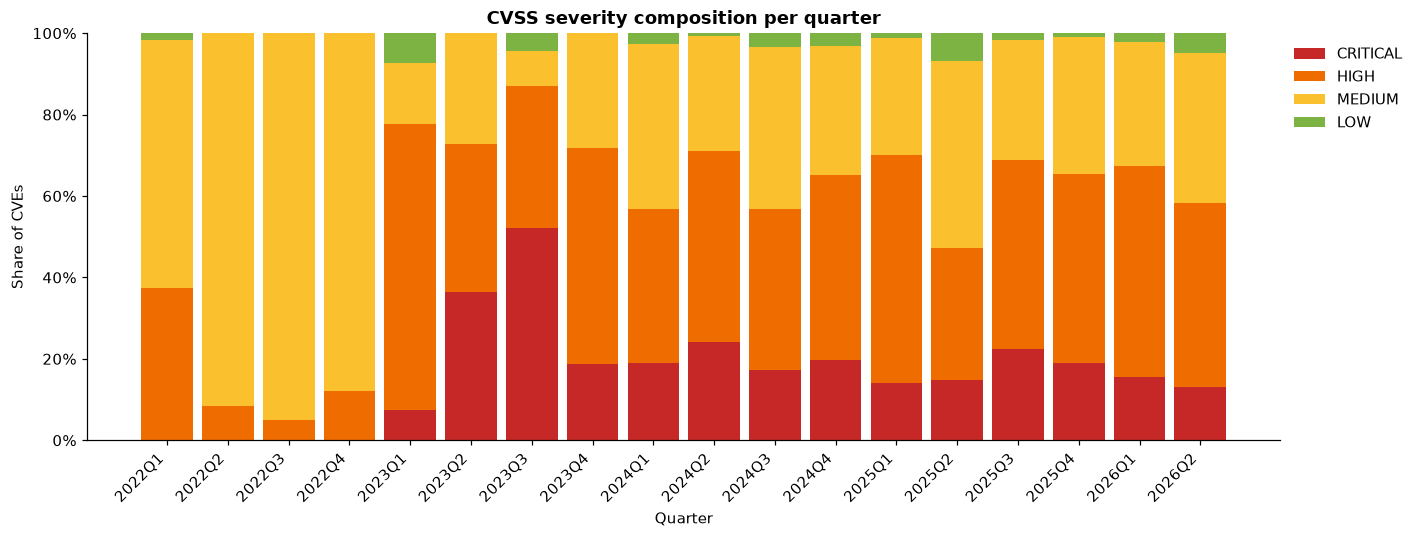

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))
sev_order = ["CRITICAL", "HIGH", "MEDIUM", "LOW"]
sev_colors = {"CRITICAL":"#c62828", "HIGH":"#ef6c00", "MEDIUM":"#fbc02d", "LOW":"#7cb342"}

sev = (scored.groupby(["quarter_str","cvss_severity"]).size()
       .unstack(fill_value=0)
       .reindex(columns=sev_order, fill_value=0).reindex(index=order))
sev_pct = sev.div(sev.sum(axis=1), axis=0).fillna(0)
bottom = np.zeros(len(sev_pct))
for s in sev_order:
    ax.bar(sev_pct.index, sev_pct[s].values, bottom=bottom,
           label=s, color=sev_colors[s], width=0.85)
    bottom += sev_pct[s].values
ax.set_ylim(0,1); ax.set_ylabel("Share of CVEs"); ax.set_xlabel("Quarter")
ax.set_title("CVSS severity composition per quarter")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y*100)}%"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(loc="upper left", bbox_to_anchor=(1.0,1.0), frameon=False)
plt.tight_layout(); plt.show()

## Figures 7 & 8: CVSS by OWASP category

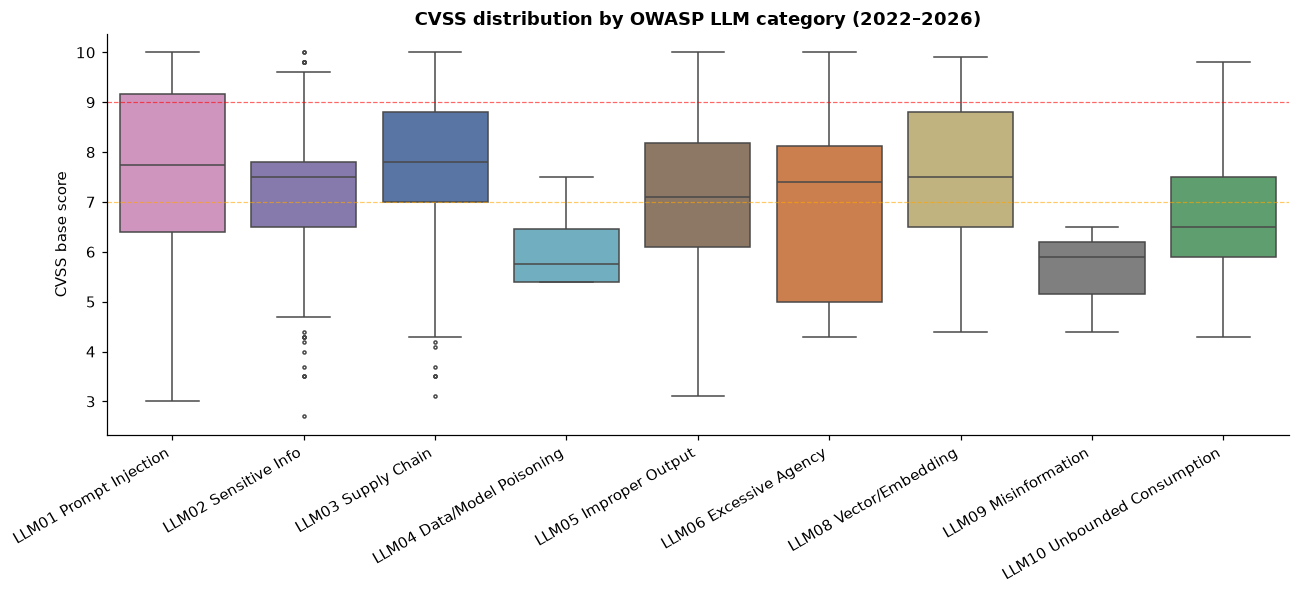

In [14]:
scored_exp = exp_full.dropna(subset=["cvss_score"]).copy()
present = [c for c in OWASP_ORDER if c in scored_exp["owasp"].unique()]

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.boxplot(data=scored_exp, x="owasp", y="cvss_score", order=present,
            hue="owasp", palette=PALETTE[:len(present)], legend=False,
            fliersize=2, ax=ax)
ax.set_xticks(range(len(present)))
ax.set_xticklabels([OWASP_SHORT[c] for c in present], rotation=30, ha="right")
ax.set_xlabel(""); ax.set_ylabel("CVSS base score")
ax.set_title("CVSS distribution by OWASP LLM category (2022–2026)")
ax.axhline(7.0, color="orange", lw=0.8, ls="--", alpha=0.6)
ax.axhline(9.0, color="red",    lw=0.8, ls="--", alpha=0.6)
plt.tight_layout(); plt.show()

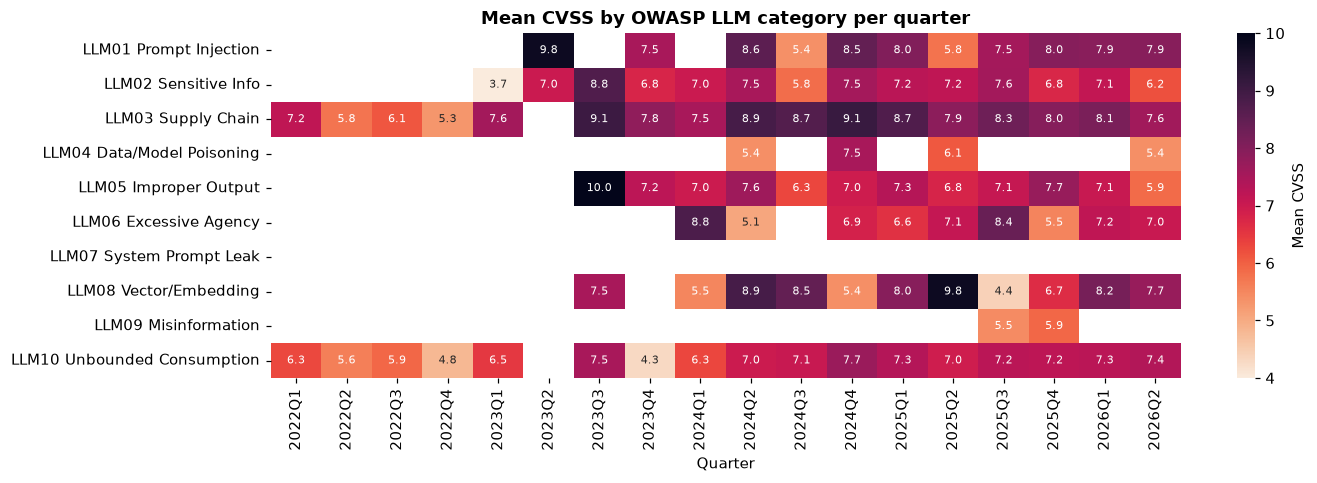

In [15]:
fig, ax = plt.subplots(figsize=(13, 4.5))
mean_hm = (scored_exp.groupby(["quarter","owasp"])["cvss_score"].mean()
           .unstack().reindex(columns=OWASP_ORDER)).T
mean_hm.index = [OWASP_SHORT[c] for c in mean_hm.index]
mean_hm.columns = [f"{d.year}Q{((d.month-1)//3)+1}" for d in mean_hm.columns]
sns.heatmap(mean_hm, cmap="rocket_r", vmin=4, vmax=10,
            annot=True, fmt=".1f", cbar_kws={"label": "Mean CVSS"},
            annot_kws={"size": 7}, ax=ax)
ax.set_xlabel("Quarter"); ax.set_ylabel("")
ax.set_title("Mean CVSS by OWASP LLM category per quarter")
plt.tight_layout(); plt.show()

## Vendor turnover by year

In [16]:
import re as _re
rows = []
for y in sorted(df_full["year"].unique()):
    vendors = []
    for s in df_full[df_full["year"]==y]["cpe_blob"].fillna(""):
        for m in _re.finditer(r"cpe:2\.3:[a-z]:([^:]+):", s):
            vendors.append(m.group(1))
    top = Counter(vendors).most_common(5)
    rows.append({"year": y, "top_vendors": ", ".join(f"{v}({n})" for v,n in top)})
pd.DataFrame(rows).set_index("year")

,top_vendors
year,
2022,"google(832), gradio_project(1), nvidia(1), lfp..."
2023,"lfprojects(21), google(21), langchain(15), min..."
2024,"mintplexlabs(42), lunary(42), gradio_project(2..."
2025,"nvidia(42), linux(33), microsoft(33), vllm(29)..."
2026,"flowiseai(25), librechat(23), nvidia(20), newa..."


In [ ]:
try:
    from google.colab import files
    files.download("llm_cves.csv")
except Exception:
    print("Not in Colab — llm_cves.csv is at:", (WORKDIR / "llm_cves.csv").resolve())

# Counterfactual baseline — the non-LLM CVEs

The two-tier filter keeps ~1.7k LLM-relevant CVEs and discards ~168k others.
On their own, the LLM-CVE trends (rising volume, rising severity) are hard to
interpret: are they LLM-specific, or do they just track the whole CVE
ecosystem, which also grows every year? This section analyses the **complement
set** — every CVE the filter rejected — as a control group, mirroring
Figures 1–3 / 5:

- **Fig 1′** non-LLM monthly volume, plus the **LLM share of all CVEs** over
  time (a direct probe of hypothesis **H4**).
- **Fig 2′/3′** severity-class composition (Critical/High/Medium/Low) over time
  — the CVSS-based analog of the OWASP composition figures, since non-LLM CVEs
  carry no OWASP-LLM category.
- **Fig 5′** CVSS distribution per quarter, and a head-to-head overlay of
  **median CVSS, LLM vs non-LLM**.

Severity is normalised with `severity_class()` (prefers NVD `baseSeverity`,
falls back to score bins for the many v2 records that omit it) so both sets use
one definition.


In [18]:
# ── Counterfactual tidy: non-LLM CVEs as a baseline/control set ───────────
# `df_non` is produced by the scan loop above. Mirror the LLM tidy (cell that
# builds df_full): parse dates, coerce CVSS, derive year/quarter/month, cap at CUT.
df_non["published"]  = pd.to_datetime(df_non["published"], errors="coerce")
df_non = df_non.dropna(subset=["published"]).copy()
df_non["cvss_score"] = pd.to_numeric(df_non["cvss_score"], errors="coerce")
df_non["year"]    = df_non["published"].dt.year
df_non["quarter"] = df_non["published"].dt.to_period("Q").dt.to_timestamp()
df_non["month"]   = df_non["published"].dt.to_period("M").dt.to_timestamp()

SEV_ORDER  = ["CRITICAL", "HIGH", "MEDIUM", "LOW"]
SEV_COLORS = {"CRITICAL":"#c62828", "HIGH":"#ef6c00", "MEDIUM":"#fbc02d", "LOW":"#7cb342"}

def severity_class(score, sev):
    """Normalised severity: prefer NVD baseSeverity, else score bins
    (NVD v2 records frequently omit baseSeverity)."""
    s = str(sev).strip().upper()
    if s in SEV_ORDER:
        return s
    if pd.isna(score):
        return None
    if score >= 9.0: return "CRITICAL"
    if score >= 7.0: return "HIGH"
    if score >= 4.0: return "MEDIUM"
    return "LOW"

df_non_full = df_non[df_non["published"] <= CUT].copy()
df_non_full["severity"] = [severity_class(sc, sv) for sc, sv in
                           zip(df_non_full["cvss_score"], df_non_full["cvss_severity"])]
# Add the same normalised severity to the LLM set for like-for-like comparison
df_full = df_full.copy()
df_full["severity"] = [severity_class(sc, sv) for sc, sv in
                       zip(df_full["cvss_score"], df_full["cvss_severity"])]

print(f"Counterfactual set: {len(df_non_full):,} non-LLM CVEs   "
      f"(LLM set: {len(df_full):,})")
non_summary = pd.DataFrame({
    "n_non_llm":   df_non_full.groupby("year").size(),
    "mean_cvss":   df_non_full.dropna(subset=["cvss_score"]).groupby("year")["cvss_score"].mean().round(2),
    "median_cvss": df_non_full.dropna(subset=["cvss_score"]).groupby("year")["cvss_score"].median(),
    "pct_high":    (df_non_full.dropna(subset=["cvss_score"])
                    .assign(hi=lambda d: d["cvss_score"]>=7.0).groupby("year")["hi"].mean()*100).round(1),
    "pct_crit":    (df_non_full.dropna(subset=["cvss_score"])
                    .assign(c=lambda d: d["cvss_score"]>=9.0).groupby("year")["c"].mean()*100).round(1),
}).fillna(0)
print("\nNon-LLM CVSS by year (compare to the LLM `summary` table earlier):")
non_summary


Counterfactual set: 156,064 non-LLM CVEs   (LLM set: 1,414)

Non-LLM CVSS by year (compare to the LLM `summary` table earlier):


,n_non_llm,mean_cvss,median_cvss,pct_high,pct_crit
year,,,,,
2022,19969,7.02,7.2,53.9,15.6
2023,27919,6.78,6.5,46.6,12.3
2024,39035,6.68,6.5,43.7,9.3
2025,48747,6.58,6.5,43.6,8.1
2026,20394,6.80,6.8,49.5,11.0


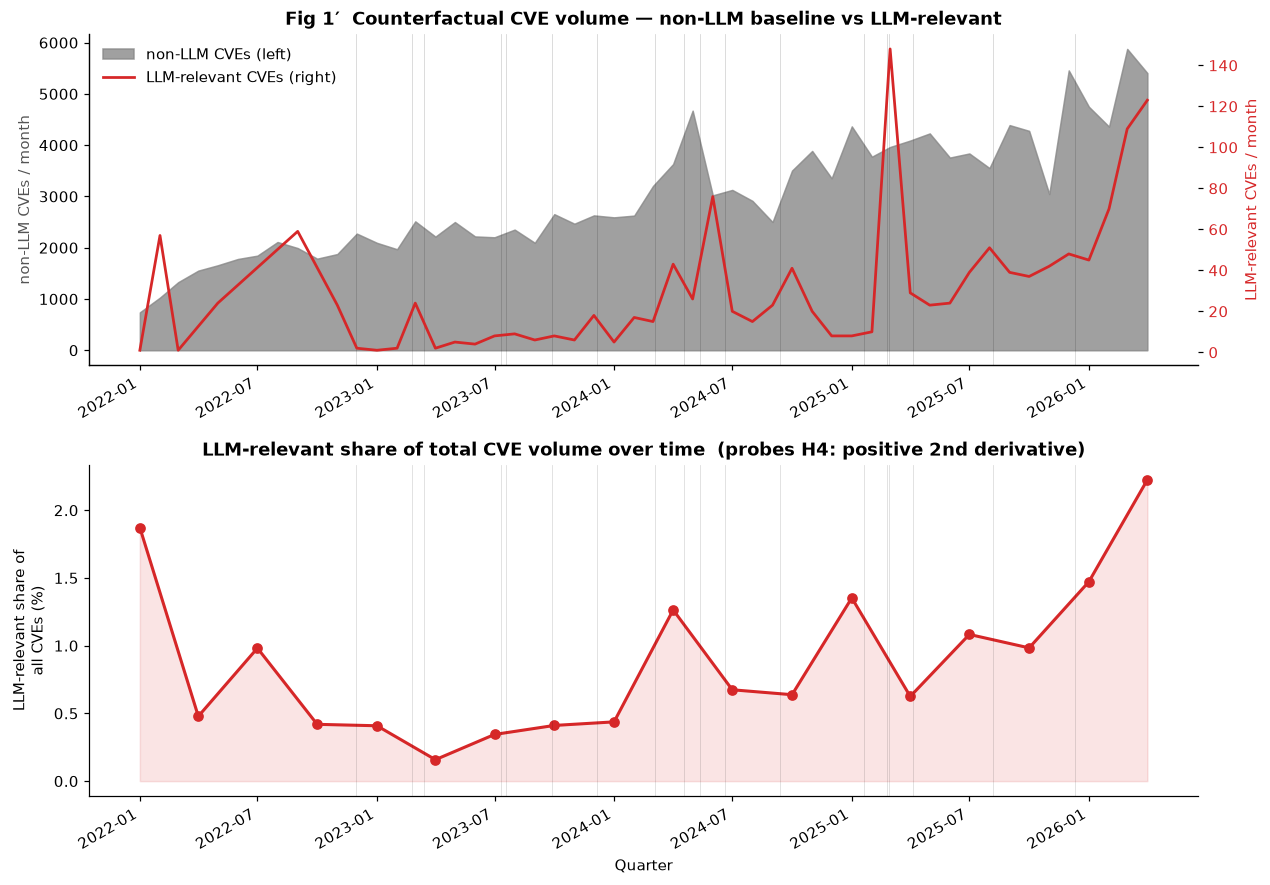

non-LLM volume: 156,064 CVEs over 52 months
LLM share of total — first quarter: 1.87%  latest: 2.22%
Saved: counterfactual_volume.png


In [19]:
# ── Fig 1′: non-LLM volume (standalone) + LLM share of all CVEs (comparison) ──
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

non_monthly = df_non_full.groupby("month").size()
llm_monthly = df_full.groupby("month").size()
non_q = df_non_full.groupby("quarter").size()
llm_q = df_full.groupby("quarter").size()
total_q = (non_q.add(llm_q, fill_value=0))
share_q = (llm_q.reindex(total_q.index, fill_value=0) / total_q * 100)

fig, (axA, axB) = plt.subplots(2, 1, figsize=(13, 9), gridspec_kw={"hspace": 0.30})

# Panel A — non-LLM monthly volume (standalone), LLM overlaid on a twin axis
axA.fill_between(non_monthly.index, non_monthly.values, color="#888888",
                 alpha=0.80, label="non-LLM CVEs (left)")
axA.set_ylabel("non-LLM CVEs / month", color="#555")
axA.set_title("Fig 1′  Counterfactual CVE volume — non-LLM baseline vs LLM-relevant")
axA2 = axA.twinx()
axA2.plot(llm_monthly.index, llm_monthly.values, color="#d62728", lw=1.8,
          label="LLM-relevant CVEs (right)")
axA2.set_ylabel("LLM-relevant CVEs / month", color="#d62728")
axA2.tick_params(axis="y", labelcolor="#d62728")
for _, r in rel_df.iterrows():
    if r["date"] <= CUT:
        axA.axvline(r["date"], color="black", lw=0.5, alpha=0.18)
axA.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
axA.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(axA.get_xticklabels(), rotation=30, ha="right")
h1, l1 = axA.get_legend_handles_labels(); h2, l2 = axA2.get_legend_handles_labels()
axA.legend(h1 + h2, l1 + l2, loc="upper left", frameon=False)
axA.spines["top"].set_visible(False); axA2.spines["top"].set_visible(False)

# Panel B — LLM share of all CVEs over time (H4 probe)
axB.plot(share_q.index, share_q.values, color="#d62728", marker="o", lw=2)
axB.fill_between(share_q.index, share_q.values, color="#d62728", alpha=0.12)
axB.set_ylabel("LLM-relevant share of\nall CVEs (%)")
axB.set_xlabel("Quarter")
axB.set_title("LLM-relevant share of total CVE volume over time  (probes H4: positive 2nd derivative)")
for _, r in rel_df.iterrows():
    if r["date"] <= CUT:
        axB.axvline(r["date"], color="black", lw=0.5, alpha=0.15)
axB.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
axB.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(axB.get_xticklabels(), rotation=30, ha="right")
axB.spines[["top", "right"]].set_visible(False)

plt.savefig("counterfactual_volume.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"non-LLM volume: {non_monthly.sum():,} CVEs over {len(non_monthly)} months")
print(f"LLM share of total — first quarter: {share_q.iloc[0]:.2f}%  "
      f"latest: {share_q.iloc[-1]:.2f}%")
print("Saved: counterfactual_volume.png")


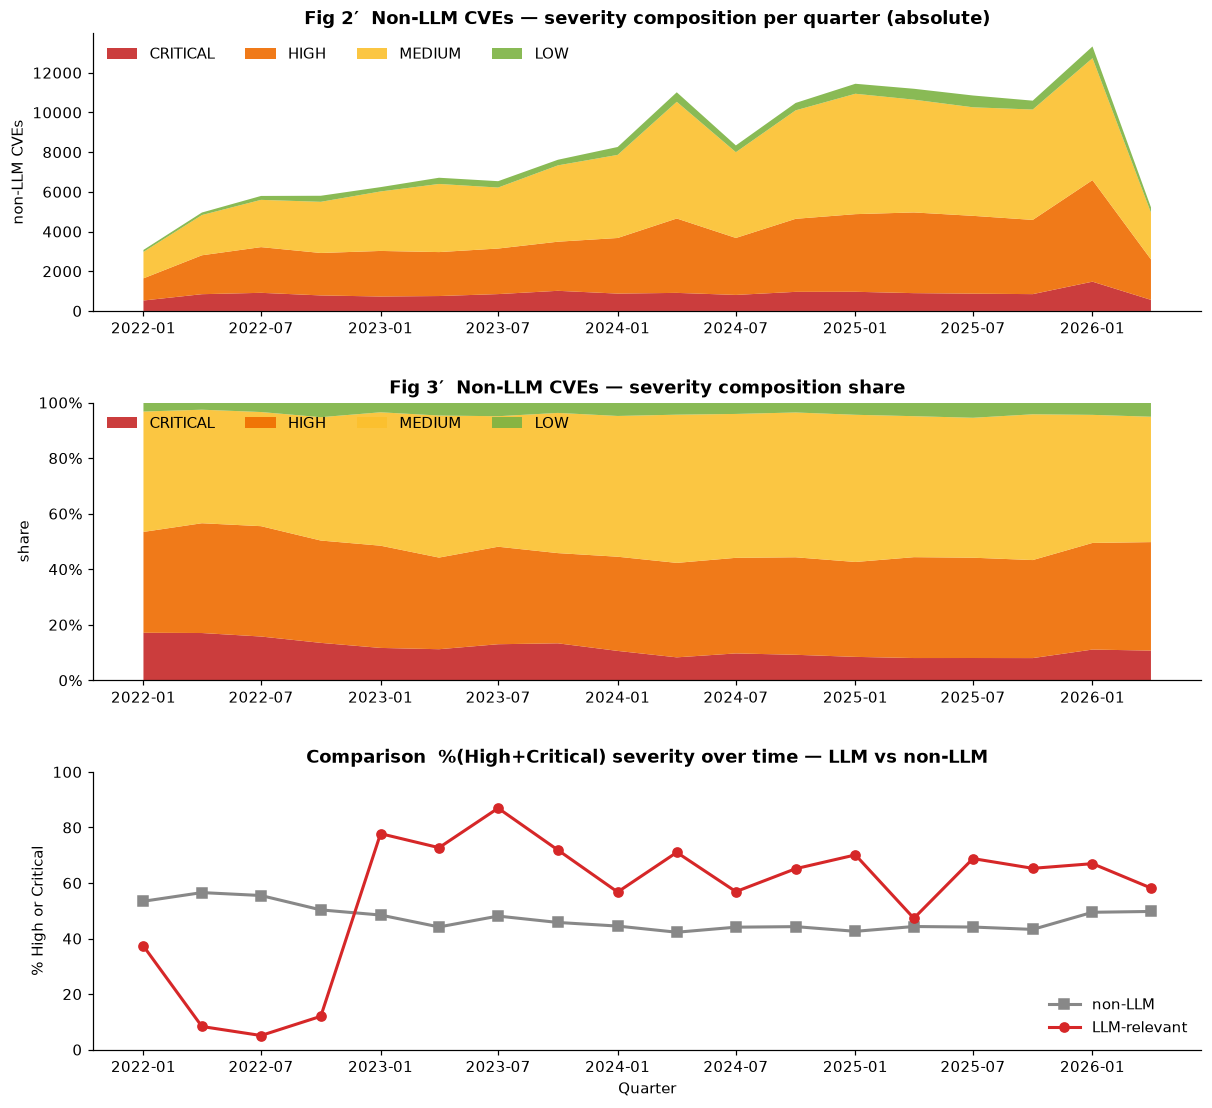

Saved: counterfactual_severity.png


In [20]:
# ── Fig 2′/3′: non-LLM severity composition + High/Critical comparison ────
import numpy as np
import matplotlib.pyplot as plt

sev_q = (df_non_full.dropna(subset=["severity"])
         .groupby(["quarter", "severity"]).size().unstack(fill_value=0)
         .reindex(columns=SEV_ORDER, fill_value=0).sort_index())
sev_share = sev_q.div(sev_q.sum(axis=1), axis=0).fillna(0)

def hc_share(d):   # %(High+Critical) per quarter
    g = d.dropna(subset=["severity"]).groupby("quarter")["severity"]
    return (g.apply(lambda s: s.isin(["HIGH", "CRITICAL"]).mean()) * 100)
hc_non, hc_llm = hc_share(df_non_full), hc_share(df_full)

fig, axes = plt.subplots(3, 1, figsize=(13, 12), gridspec_kw={"hspace": 0.33})

# Fig 2′ — absolute severity counts (stacked area)
axes[0].stackplot(sev_q.index, [sev_q[s].values for s in SEV_ORDER],
                  labels=SEV_ORDER, colors=[SEV_COLORS[s] for s in SEV_ORDER], alpha=0.9)
axes[0].set_title("Fig 2′  Non-LLM CVEs — severity composition per quarter (absolute)")
axes[0].set_ylabel("non-LLM CVEs")
axes[0].legend(loc="upper left", frameon=False, ncol=4)

# Fig 3′ — severity share (100% stacked area)
axes[1].stackplot(sev_share.index, [sev_share[s].values for s in SEV_ORDER],
                  labels=SEV_ORDER, colors=[SEV_COLORS[s] for s in SEV_ORDER], alpha=0.9)
axes[1].set_ylim(0, 1)
axes[1].set_title("Fig 3′  Non-LLM CVEs — severity composition share")
axes[1].set_ylabel("share")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y*100)}%"))
axes[1].legend(loc="upper left", frameon=False, ncol=4)

# Comparison — %(High+Critical) LLM vs non-LLM
axes[2].plot(hc_non.index, hc_non.values, color="#888888", marker="s", lw=2, label="non-LLM")
axes[2].plot(hc_llm.index, hc_llm.values, color="#d62728", marker="o", lw=2, label="LLM-relevant")
axes[2].set_ylim(0, 100)
axes[2].set_title("Comparison  %(High+Critical) severity over time — LLM vs non-LLM")
axes[2].set_ylabel("% High or Critical"); axes[2].set_xlabel("Quarter")
axes[2].legend(loc="lower right", frameon=False)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

plt.savefig("counterfactual_severity.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved: counterfactual_severity.png")


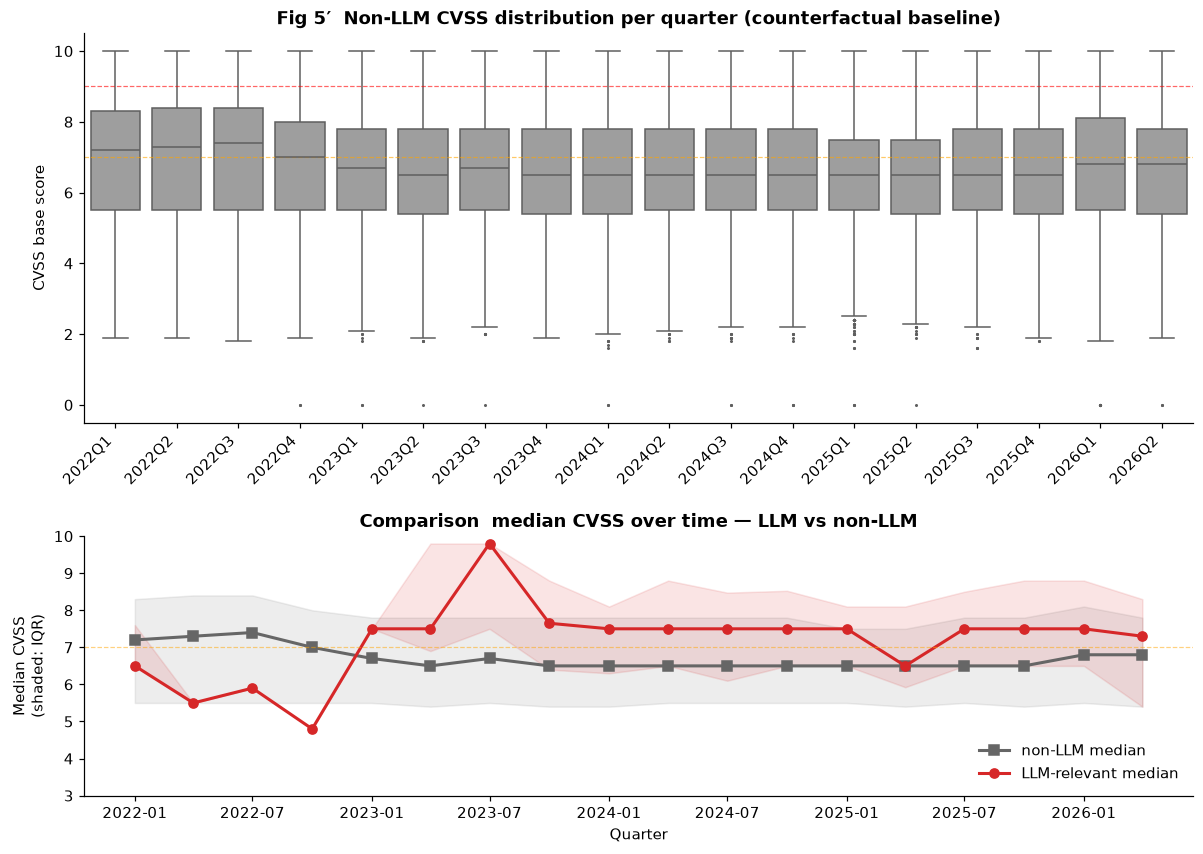

Overall median CVSS — non-LLM: 6.5  |  LLM-relevant: 7.5
Saved: counterfactual_cvss.png


In [21]:
# ── Fig 5′: non-LLM CVSS distribution + median-CVSS comparison overlay ────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def _qstr(d):
    return d.apply(lambda x: f"{x.year}Q{((x.month-1)//3)+1}")

non_sc = df_non_full.dropna(subset=["cvss_score"]).copy()
non_sc["quarter_str"] = _qstr(non_sc["quarter"])
order = sorted(non_sc["quarter_str"].unique(), key=lambda q: (int(q[:4]), int(q[-1])))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9),
                               gridspec_kw={"height_ratios": [3, 2], "hspace": 0.35})

# Panel 1 — non-LLM CVSS boxplot per quarter (standalone, mirrors Fig 5)
sns.boxplot(data=non_sc, x="quarter_str", y="cvss_score", order=order,
            color="#9e9e9e", fliersize=1, ax=ax1)
ax1.axhline(7.0, color="orange", lw=0.8, ls="--", alpha=0.6)
ax1.axhline(9.0, color="red",    lw=0.8, ls="--", alpha=0.6)
ax1.set_ylabel("CVSS base score"); ax1.set_xlabel("")
ax1.set_title("Fig 5′  Non-LLM CVSS distribution per quarter (counterfactual baseline)")
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# Panel 2 — median CVSS (+IQR band) LLM vs non-LLM (headline comparison)
def med_iqr(d):
    g = d.dropna(subset=["cvss_score"]).groupby("quarter")["cvss_score"]
    return g.median(), g.quantile(0.25), g.quantile(0.75)
nm, nlo, nhi = med_iqr(df_non_full)
lm, llo, lhi = med_iqr(df_full)
ax2.plot(nm.index, nm.values, color="#666666", marker="s", lw=2, label="non-LLM median")
ax2.fill_between(nm.index, nlo.values, nhi.values, color="#888888", alpha=0.15)
ax2.plot(lm.index, lm.values, color="#d62728", marker="o", lw=2, label="LLM-relevant median")
ax2.fill_between(lm.index, llo.values, lhi.values, color="#d62728", alpha=0.12)
ax2.axhline(7.0, color="orange", lw=0.8, ls="--", alpha=0.5)
ax2.set_ylim(3, 10)
ax2.set_ylabel("Median CVSS\n(shaded: IQR)"); ax2.set_xlabel("Quarter")
ax2.set_title("Comparison  median CVSS over time — LLM vs non-LLM")
ax2.legend(loc="lower right", frameon=False)
ax2.spines[["top", "right"]].set_visible(False)

plt.savefig("counterfactual_cvss.png", dpi=140, bbox_inches="tight")
plt.show()
ov_non = df_non_full["cvss_score"].median()
ov_llm = df_full["cvss_score"].median()
print(f"Overall median CVSS — non-LLM: {ov_non:.1f}  |  LLM-relevant: {ov_llm:.1f}")
print("Saved: counterfactual_cvss.png")


# Classifier comparison: regex vs BM25

The LLM-relevance decision is currently a hand-tuned **regex** (`classify_relevance`).
This section brings in a **BM25** second opinion — a graded, rarity-weighted,
length-normalized relevance score computed by the standalone module
[`bm25_relevance.py`](bm25_relevance.py) (which also carries a full explanation of
how BM25 works in its docstring). BM25 does **not** replace the regex here; we run
both on every CVE and study where they **disagree**:

- **BM25-only** (high BM25 score, regex says *not* relevant) → candidate CVEs the
  regex **misses**.
- **regex-only** (regex says relevant, low BM25 score) → candidate regex
  **false positives**.

Those two lists are exactly the material for the planned human-adjudication /
classifier-audit step. The regex is treated as a *reference*, not ground truth.

**Heavy compute lives in the module** (walking ~170k NVD JSON files, fitting BM25,
scoring) and is meant to run once — locally if the NVD clone is present, or on a
GCP VM: `python bm25_relevance.py --nvd <nvd_dir> --out bm25_comparison.csv`.
The cells below just load that CSV and analyse it.


In [ ]:
# ── Load (or build) the regex-vs-BM25 comparison table ────────────────────
import sys
from pathlib import Path
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path(WORKDIR).parent))   # repo root holds bm25_relevance.py
CMP_CSV = Path(WORKDIR) / "bm25_comparison.csv"

bm25_ready = False
if CMP_CSV.exists():
    cmp = pd.read_csv(CMP_CSV)
    bm25_ready = True
    print(f"Loaded {CMP_CSV}  ({len(cmp):,} CVEs)")
else:
    nvd_dir = Path(WORKDIR) / "nvd"
    if nvd_dir.exists():
        import bm25_relevance as B
        print("No comparison CSV yet — building it from the local NVD clone "
              "(one-off, ~1-3 min)...")
        B.build_comparison(nvd_dir, out_csv=CMP_CSV)
        cmp = pd.read_csv(CMP_CSV)
        bm25_ready = True
    else:
        print("bm25_comparison.csv not found, and no NVD clone at", nvd_dir)
        print("Generate it once with:")
        print(f"    python bm25_relevance.py --nvd <nvd_dir> --out {CMP_CSV}")
        print("(e.g. on a GCP VM over the full corpus), then copy the CSV here "
              "and re-run this cell.")

if bm25_ready:
    cmp["regex_is_relevant"] = cmp["regex_is_relevant"].astype(bool)
    cmp["bm25_is_relevant"]  = cmp["bm25_is_relevant"].astype(bool)
    n = len(cmp)
    agree      = float((cmp["bm25_is_relevant"] == cmp["regex_is_relevant"]).mean())
    bm25_only  = cmp[cmp["bm25_is_relevant"] & ~cmp["regex_is_relevant"]]
    regex_only = cmp[~cmp["bm25_is_relevant"] & cmp["regex_is_relevant"]]
    both       = int((cmp["bm25_is_relevant"] & cmp["regex_is_relevant"]).sum())
    print(f"\nCVEs scored:        {n:,}")
    print(f"regex-relevant:     {int(cmp['regex_is_relevant'].sum()):,}")
    print(f"BM25-relevant:      {int(cmp['bm25_is_relevant'].sum()):,}")
    print(f"agreement:          {agree*100:.2f}%")
    print(f"  both agree keep:  {both:,}")
    print(f"  BM25-only (regex MISSES?):        {len(bm25_only):,}")
    print(f"  regex-only (regex FALSE POS?):    {len(regex_only):,}")


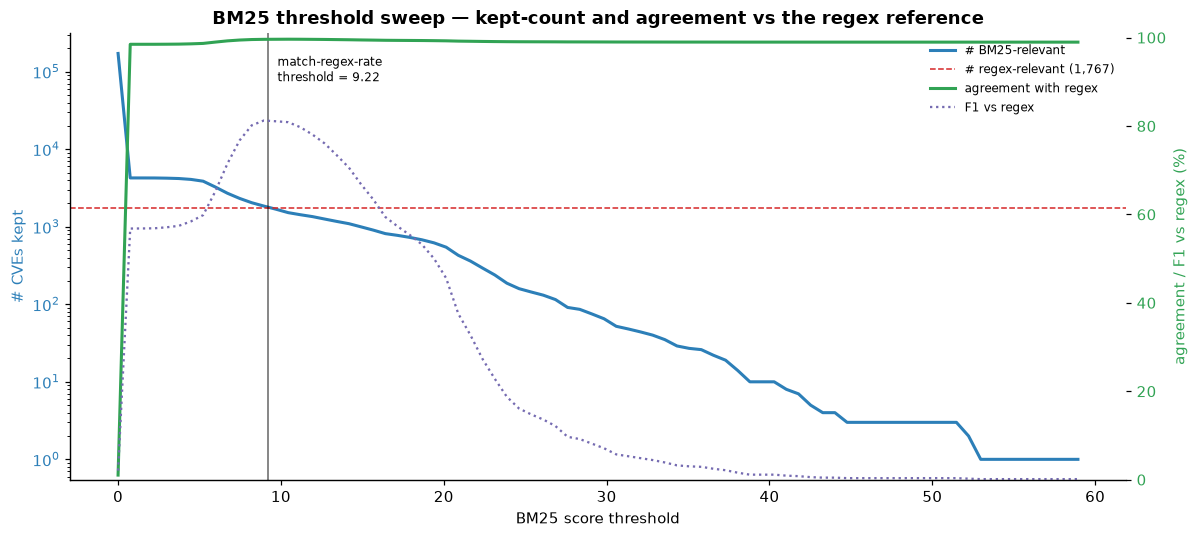

Saved: bm25_threshold_sweep.png


In [23]:
# ── Threshold sweep: the precision/recall tradeoff, visualised ────────────
import matplotlib.pyplot as plt
import bm25_relevance as B

if not bm25_ready:
    print("Skipped — no comparison data loaded (see the cell above).")
else:
    scores = cmp["bm25_score"].to_numpy()
    reg    = cmp["regex_is_relevant"].to_numpy()
    sw     = B.sweep_thresholds(scores, reg, n_steps=80)
    thr_match = B.suggest_threshold(scores, reg, "match_regex_rate")

    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax1.plot(sw["threshold"], sw["bm25_pos"], color="#2c7fb8", lw=2,
             label="# BM25-relevant")
    ax1.axhline(int(reg.sum()), color="#d62728", ls="--", lw=1,
                label=f"# regex-relevant ({int(reg.sum()):,})")
    ax1.set_xlabel("BM25 score threshold")
    ax1.set_ylabel("# CVEs kept", color="#2c7fb8")
    ax1.tick_params(axis="y", labelcolor="#2c7fb8")
    ax1.set_yscale("log")

    ax2 = ax1.twinx()
    ax2.plot(sw["threshold"], sw["agreement"]*100, color="#31a354", lw=2,
             label="agreement with regex")
    ax2.plot(sw["threshold"], sw["f1_vs_regex"]*100, color="#756bb1", lw=1.5,
             ls=":", label="F1 vs regex")
    ax2.set_ylabel("agreement / F1 vs regex (%)", color="#31a354")
    ax2.tick_params(axis="y", labelcolor="#31a354")
    ax2.set_ylim(0, 101)

    ax1.axvline(thr_match, color="black", lw=1, alpha=0.6)
    ax1.annotate(f"match-regex-rate\nthreshold = {thr_match:.2f}",
                 xy=(thr_match, ax1.get_ylim()[1]), xytext=(6, -14),
                 textcoords="offset points", fontsize=8, va="top")
    h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc="upper right", fontsize=8, frameon=False)
    ax1.set_title("BM25 threshold sweep — kept-count and agreement vs the regex reference")
    ax1.spines["top"].set_visible(False); ax2.spines["top"].set_visible(False)
    plt.tight_layout()
    plt.savefig("bm25_threshold_sweep.png", dpi=140, bbox_inches="tight")
    plt.show()
    print("Saved: bm25_threshold_sweep.png")


In [ ]:
# ── The disagreements — the list for human adjudication ───────────────────
if not bm25_ready:
    print("Skipped — no comparison data loaded (see the load cell above).")
else:
    TOP = 15
    cols = ["cve_id", "published", "bm25_score", "regex_relevance", "desc_snippet"]

    print("="*100)
    print(f"TOP {TOP} BM25-ONLY  (high BM25 score, regex said NOT relevant → candidate regex MISSES)")
    print("="*100)
    bo = (cmp[cmp["bm25_is_relevant"] & ~cmp["regex_is_relevant"]]
          .sort_values("bm25_score", ascending=False).head(TOP))
    for _, r in bo.iterrows():
        print(f"[{r['bm25_score']:6.2f}] {r['cve_id']}  {str(r['desc_snippet'])[:110]}")
    if bo.empty:
        print("  (none)")

    print("\n" + "="*100)
    print(f"LOWEST-SCORING {TOP} REGEX-ONLY  (regex said relevant, low BM25 → candidate regex FALSE POSITIVES)")
    print("="*100)
    ro = (cmp[~cmp["bm25_is_relevant"] & cmp["regex_is_relevant"]]
          .sort_values("bm25_score", ascending=True).head(TOP))
    for _, r in ro.iterrows():
        print(f"[{r['bm25_score']:6.2f}] {r['cve_id']}  ({r['regex_relevance']})  "
              f"{str(r['desc_snippet'])[:95]}")
    if ro.empty:
        print("  (none)")

    # expose the full disagreement frames for downstream inspection / export
    bm25_only_df  = cmp[cmp["bm25_is_relevant"] & ~cmp["regex_is_relevant"]].sort_values("bm25_score", ascending=False)
    regex_only_df = cmp[~cmp["bm25_is_relevant"] & cmp["regex_is_relevant"]].sort_values("bm25_score")
    print(f"\nFull disagreement sets available as `bm25_only_df` ({len(bm25_only_df):,}) "
          f"and `regex_only_df` ({len(regex_only_df):,}).")


## BM25 variants, and reading the regex-misses

Two follow-ups to the regex-vs-BM25 comparison:

1. **Variant comparison** — score the same corpus under **Okapi**, **BM25L**, and
   **BM25+**. Empirically (full NVD corpus): BM25+ is rank-identical to Okapi
   under a top-N threshold (its δ enters as a near-uniform baseline), while
   **BM25L** diverges from the regex (Jaccard ~68% → ~49%) and its extra
   "regex-miss" candidates are ~6× longer than the corpus average — its
   length-rehabilitation pulls in long, incidental-mention CVEs. Conclusion:
   **plain Okapi is the right default here.** The figure below shows the
   agreement drop and the length skew.

2. **Reading Okapi's regex-misses** — the ~331 CVEs BM25 keeps but the regex
   drops are triaged by whether they contain an unambiguously-LLM
   (`HIGH_SIGNAL_TERMS`) term vs only generic ML vocabulary. The high-signal
   subset is the priority list for human adjudication — genuine LLM CVEs the
   regex lexicon may not yet cover.


Scoring corpus under okapi / BM25L / BM25+  (~1 min)...

variant  threshold  bm25_pos  agreement_%  bm25_only  regex_only  jaccard_%  bm25_only_mean_len  corpus_mean_len
  okapi      9.224      1768       99.615        331         330      68.49                63.5            107.8
      l     21.746      1767       99.290        610         610      48.67               639.0            107.8
   plus    719.524      1768       99.615        331         330      68.49                63.5            107.8

CVEs whose keep/discard flips between Okapi and BM25+: 0
  BM25+ keeps but Okapi drops: 0   |   Okapi keeps but BM25+ drops: 0


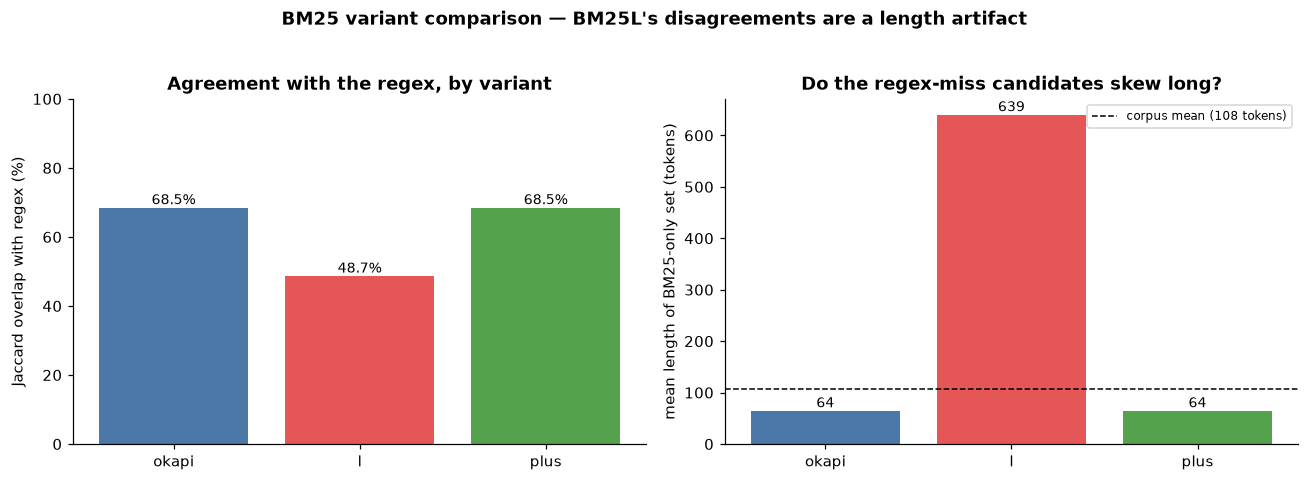


Saved: bm25_variant_comparison.png


In [25]:
# ── Variant comparison: Okapi vs BM25L vs BM25+ (re-walks NVD, ~1 min) ─────
import matplotlib.pyplot as plt
import bm25_relevance as B

nvd_dir = Path(WORKDIR) / "nvd"
if not nvd_dir.exists():
    print("Skipped — needs the local NVD clone at", nvd_dir)
    print("(This cell re-scores the whole corpus under each variant; ~1 min.)")
else:
    print("Scoring corpus under okapi / BM25L / BM25+  (~1 min)...\n")
    var_summary, var_df = B.compare_variants(nvd_dir)   # prints its own table

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.2))
    cols = ["#4c78a8", "#e45756", "#54a24b"]
    v = var_summary["variant"].tolist()

    axL.bar(v, var_summary["jaccard_%"], color=cols)
    axL.set_ylabel("Jaccard overlap with regex (%)"); axL.set_ylim(0, 100)
    axL.set_title("Agreement with the regex, by variant")
    for i, val in enumerate(var_summary["jaccard_%"]):
        axL.text(i, val + 1, f"{val:.1f}%", ha="center", fontsize=9)

    axR.bar(v, var_summary["bm25_only_mean_len"], color=cols)
    corpus_len = float(var_summary["corpus_mean_len"].iloc[0])
    axR.axhline(corpus_len, color="black", ls="--", lw=1,
                label=f"corpus mean ({corpus_len:.0f} tokens)")
    axR.set_ylabel("mean length of BM25-only set (tokens)")
    axR.set_title("Do the regex-miss candidates skew long?")
    axR.legend(fontsize=8)
    for i, val in enumerate(var_summary["bm25_only_mean_len"]):
        axR.text(i, val + 8, f"{val:.0f}", ha="center", fontsize=9)

    for ax in (axL, axR):
        ax.spines[["top", "right"]].set_visible(False)
    plt.suptitle("BM25 variant comparison — BM25L's disagreements are a length artifact",
                 fontsize=11.5, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig("bm25_variant_comparison.png", dpi=140, bbox_inches="tight")
    plt.show()
    print("\nSaved: bm25_variant_comparison.png")


In [ ]:
# ── Reading Okapi's regex-misses: the priority list for adjudication ──────
if not bm25_ready:
    print("Skipped — no comparison data loaded (see the load cell above).")
elif "matched_terms" not in cmp.columns:
    print("Your bm25_comparison.csv predates the `matched_terms` column.")
    print("Regenerate it with the updated module, then re-run:")
    print(f"    python bm25_relevance.py --nvd <nvd_dir> --out {CMP_CSV}")
else:
    bo = (cmp[cmp["bm25_is_relevant"] & ~cmp["regex_is_relevant"]]
          .sort_values("bm25_score", ascending=False)).copy()
    bo["high_signal"] = bo["high_signal"].astype(bool)
    hs  = bo[bo["high_signal"]]
    gen = bo[~bo["high_signal"]]
    print(f"Okapi BM25-only (regex-MISS) candidates: {len(bo)}")
    print(f"  high-signal (genuine-looking LLM CVEs): {len(hs)}   "
          f"mean len {hs['doc_len'].mean():.0f} tok")
    print(f"  generic/weak-only (likely ML noise):    {len(gen)}   "
          f"mean len {gen['doc_len'].mean():.0f} tok")

    print("\n" + "=" * 104)
    print(f"TOP {min(25, len(hs))} HIGH-SIGNAL regex-misses  — priority list for human adjudication")
    print("(«matched query terms»  →  is this a genuine LLM CVE the regex lexicon missed?)")
    print("=" * 104)
    for _, r in hs.head(25).iterrows():
        print(f"[{r['bm25_score']:6.2f}] {r['cve_id']}  «{r['matched_terms']}»")
        print(f"          {str(r['desc_snippet'])[:150]}")

    print("\n" + "-" * 104)
    print(f"For contrast — a few GENERIC/weak-only BM25-only CVEs (why a naive score threshold over-keeps):")
    print("-" * 104)
    for _, r in gen.head(6).iterrows():
        print(f"[{r['bm25_score']:6.2f}] {r['cve_id']}  «{r['matched_terms']}»  "
              f"{str(r['desc_snippet'])[:90]}")

    # Export the priority list for the annotation / classifier-audit step
    regex_miss_candidates = hs[["cve_id", "published", "bm25_score", "matched_terms", "desc_snippet"]]
    _out = Path(WORKDIR) / "regex_miss_candidates.csv"
    regex_miss_candidates.to_csv(_out, index=False)
    print(f"\n`regex_miss_candidates` ({len(hs)} rows) written to {_out} for review.")


# Additional Question

How do the metrics capture reflect on safety benchmarks? Do the benchmarks that supposely capture what the safety benchmarks are saying? We should also review the system cards from the big models historically.


## Model Card Cyber Evaluation Data — Loading and Mapping

Loads `model_card_cyber_evals.csv` scraped from major lab system cards (Anthropic, OpenAI,
Google DeepMind, Meta, DeepSeek), parses quantitative cyber evaluation metrics, and builds
the `bench` / `bench_extended` DataFrames used by the trendline and decoupling analysis below.
Also defines `SHORT_FULL`, `ALL_CATS`, and `cvss_q` (quarterly CVSS by OWASP category).

**Metrics extracted:**
- **Anthropic:** CTF per-category solve rates (Web / Crypto / Pwn / Rev / Network), Cybench pass@30, CyberGym score %
- **OpenAI:** HS / Collegiate / Professional CTF %, Cyber Range pass %, Preparedness risk level (Low → High)
- **Google DeepMind:** CTF easy / medium / hard solve rates, Autonomous Offense solve rates
- **Cross-lab:** Cybench pass@30 (Anthropic), Firefox 147 full exploit %

**Framing:** all metrics use `direction="L"` (lower offensive capability = safer), so a
normalised score of **1.0 means safest observed** and **0.0 means most capable / least safe**.
A rising `norm` trend over time means a vendor's models are getting *comparatively safer*
on that metric — cross against CVSS trends in the decoupling analysis below.

In [ ]:
import re as _re

# ── Auxiliary mappings (required by trendline + decoupling cells below) ───
SHORT_FULL = {
    "LLM01": "LLM01_Prompt_Injection",
    "LLM02": "LLM02_Sensitive_Info_Disclosure",
    "LLM03": "LLM03_Supply_Chain",
    "LLM04": "LLM04_Data_Model_Poisoning",
    "LLM05": "LLM05_Improper_Output_Handling",
    "LLM06": "LLM06_Excessive_Agency",
    "LLM07": "LLM07_System_Prompt_Leakage",
    "LLM08": "LLM08_Vector_Embedding_Weakness",
    "LLM09": "LLM09_Misinformation",
    "LLM10": "LLM10_Unbounded_Consumption",
}
ALL_CATS = [SHORT_FULL[f"LLM{i:02d}"] for i in range(1, 11)]

# ── cvss_q: quarterly mean CVSS per OWASP category (from main pipeline) ──
# Degrades gracefully if the CVE pipeline (exp_full) has not been run on this
# machine. The model-card analysis below is independent of the CVE data and
# uses cvss_q only as an optional overlay, so an empty frame is fine.
try:
    cvss_q = (exp_full.dropna(subset=["cvss_score"])
               .groupby(["quarter", "owasp"])["cvss_score"]
               .mean()
               .reset_index())
except NameError:
    cvss_q = pd.DataFrame(columns=["quarter", "owasp", "cvss_score"])
if cvss_q.empty:
    print("cvss_q: EMPTY (CVE data not loaded — CVSS overlay will be skipped)")
else:
    print(f"cvss_q: {len(cvss_q)} rows  |  {cvss_q['owasp'].nunique()} OWASP categories")

# ── Parsers ───────────────────────────────────────────────────────────────
def _f(s):
    try:
        return float(str(s).strip())
    except (ValueError, TypeError):
        return float("nan")

def parse_cybench(s):
    """'15/34 (44%)' → 44.0;  '60' → 60.0;  '' → NaN."""
    s = str(s).strip()
    if not s:
        return float("nan")
    m = _re.search(r"\(([0-9.]+)%\)", s)
    if m:
        return float(m.group(1))
    m = _re.search(r"^([0-9.]+)", s)
    return float(m.group(1)) if m else float("nan")

def solve_rate(solved, total):
    s, t = _f(solved), _f(total)
    if pd.isna(s) or pd.isna(t) or t == 0:
        return float("nan")
    return s / t * 100

def risk_to_numeric(s):
    s = str(s).strip().lower()
    if s.startswith("low"):        return 1.0
    if s.startswith("medium"):     return 2.0
    if "below critical" in s:      return 3.5
    if s.startswith("high"):       return 3.0
    return float("nan")

VENDOR_MAP = {"Google DeepMind": "Google"}

# ── Metric extraction spec ────────────────────────────────────────────────
# (metric_label, extractor, family, owasp_keys, direction, source)
# direction="L": lower offensive capability = safer → norm=1.0 is safest
METRIC_SPECS = [
    ("CTF Web Solve %",
     lambda r: solve_rate(r.get("ctf_web_solved"), r.get("ctf_web_total")),
     "CTF Solve Rate", ["LLM01", "LLM05"], "L", "Anthropic Fixed CTF suite"),
    ("CTF Crypto Solve %",
     lambda r: solve_rate(r.get("ctf_crypto_solved"), r.get("ctf_crypto_total")),
     "CTF Solve Rate", ["LLM02"], "L", "Anthropic Fixed CTF suite"),
    ("CTF Pwn Solve %",
     lambda r: solve_rate(r.get("ctf_pwn_solved"), r.get("ctf_pwn_total")),
     "CTF Solve Rate", ["LLM06", "LLM03"], "L", "Anthropic Fixed CTF suite"),
    ("CTF Rev Solve %",
     lambda r: solve_rate(r.get("ctf_rev_solved"), r.get("ctf_rev_total")),
     "CTF Solve Rate", ["LLM06", "LLM03"], "L", "Anthropic Fixed CTF suite"),
    ("CTF Network Solve %",
     lambda r: solve_rate(r.get("ctf_network_solved"), r.get("ctf_network_total")),
     "CTF Solve Rate", ["LLM06"], "L", "Anthropic Fixed CTF suite"),
    ("Cybench Pass@30 %",
     lambda r: parse_cybench(r.get("cybench_score", "")),
     "Cybench Pass@30", ["LLM01", "LLM06"], "L", "Cybench benchmark"),
    ("CyberGym Score %",
     lambda r: _f(r.get("cybergym_score_pct", "")),
     "Agentic Offense (CyberGym)", ["LLM06"], "L", "CyberGym benchmark"),
    ("OpenAI HS CTF %",
     lambda r: _f(r.get("openai_hs_ctf_pct", "")),
     "CTF Solve Rate", ["LLM01", "LLM06"], "L", "OpenAI Preparedness CTF"),
    ("OpenAI Collegiate CTF %",
     lambda r: _f(r.get("openai_collegiate_ctf_pct", "")),
     "CTF Solve Rate", ["LLM01", "LLM06"], "L", "OpenAI Preparedness CTF"),
    ("OpenAI Professional CTF %",
     lambda r: _f(r.get("openai_professional_ctf_pct", "")),
     "CTF Solve Rate", ["LLM01", "LLM06"], "L", "OpenAI Preparedness CTF"),
    ("Cyber Range Pass %",
     lambda r: _f(r.get("openai_cyber_range_pass_rate_pct", "")),
     "Cyber Range", ["LLM06"], "L", "OpenAI Cyber Range"),
    ("Cyber Risk Level",
     lambda r: risk_to_numeric(r.get("openai_preparedness_cyber_risk_pre_mitigation", "")),
     "Cyber Risk Rating", ["LLM01", "LLM06"], "L", "OpenAI Preparedness Framework"),
    ("Firefox Exploit Full %",
     lambda r: _f(r.get("firefox_exploit_full_pct", "")),
     "Exploit Development", ["LLM05", "LLM06"], "L", "Firefox 147 exploit eval"),
    ("Google CTF Easy %",
     lambda r: solve_rate(r.get("google_ctf_easy_solved"), r.get("google_ctf_easy_total")),
     "CTF Solve Rate", ["LLM01", "LLM06"], "L", "Google DeepMind CTF eval"),
    ("Google CTF Medium %",
     lambda r: solve_rate(r.get("google_ctf_medium_solved"), r.get("google_ctf_medium_total")),
     "CTF Solve Rate", ["LLM01", "LLM06"], "L", "Google DeepMind CTF eval"),
    ("Google CTF Hard %",
     lambda r: solve_rate(r.get("google_ctf_hard_solved"), r.get("google_ctf_hard_total")),
     "CTF Solve Rate", ["LLM01", "LLM06"], "L", "Google DeepMind CTF eval"),
    ("Google Autonomous Easy %",
     lambda r: solve_rate(r.get("google_autonomous_offense_easy_solved"),
                          r.get("google_autonomous_offense_easy_total")),
     "Autonomous Offense", ["LLM06"], "L", "Google DeepMind Autonomous Offense eval"),
    ("Google Autonomous Medium %",
     lambda r: solve_rate(r.get("google_autonomous_offense_medium_solved"),
                          r.get("google_autonomous_offense_medium_total")),
     "Autonomous Offense", ["LLM06"], "L", "Google DeepMind Autonomous Offense eval"),
]

# ── Load CSV ───────────────────────────────────────────────────────────────
# Search upward from WORKDIR and cwd for the source CSV (robust to a nested
# WORKDIR — it lives at the repo root, which is an ancestor of both).
def _find_up(name, *starts):
    seen = []
    for s in starts:
        s = Path(s)
        for base in (s, *s.parents):
            cand = base / name
            seen.append(cand)
            if cand.exists():
                return cand, seen
    return None, seen
_csv_path, _tried = _find_up("model_card_cyber_evals.csv", Path(WORKDIR), Path.cwd())
assert _csv_path is not None, (
    "Cannot find model_card_cyber_evals.csv by searching up from "
    f"{Path(WORKDIR)} and {Path.cwd()}")
print(f"Loading: {_csv_path}")

mc = pd.read_csv(_csv_path, dtype=str).fillna("")

# ── Build long-format bench DataFrame ─────────────────────────────────────
bench_records = []
for _, row in mc.iterrows():
    model        = str(row.get("model_name", "")).strip()
    vendor_raw   = str(row.get("lab", "")).strip()
    date_s       = str(row.get("card_date", "")).strip()
    if not model or not date_s:
        continue
    try:
        release_date = pd.to_datetime(date_s)
    except Exception:
        continue
    vendor = VENDOR_MAP.get(vendor_raw, vendor_raw)

    for metric_label, extractor, family, owasp_keys, direction, source_label in METRIC_SPECS:
        try:
            value = extractor(row)
        except Exception:
            value = float("nan")
        if pd.isna(value):
            continue
        for owasp_key in owasp_keys:
            bench_records.append({
                "model":        model,
                "vendor":       vendor,
                "release_date": release_date,
                "metric":       metric_label,
                "value":        value,
                "direction":    direction,
                "family":       family,
                "owasp":        SHORT_FULL[owasp_key],
                "source":       f"[{source_label}]",
                "ci_half":      float("nan"),
            })

bench    = pd.DataFrame(bench_records)
new_rows = pd.DataFrame(columns=bench.columns)   # empty placeholder for cell below

print(f"\nbench: {len(bench)} rows  |  models: {bench['model'].nunique()}  "
      f"|  vendors: {bench['vendor'].unique().tolist()}")
bench.groupby(["vendor", "family"])["model"].nunique().unstack(fill_value=0)

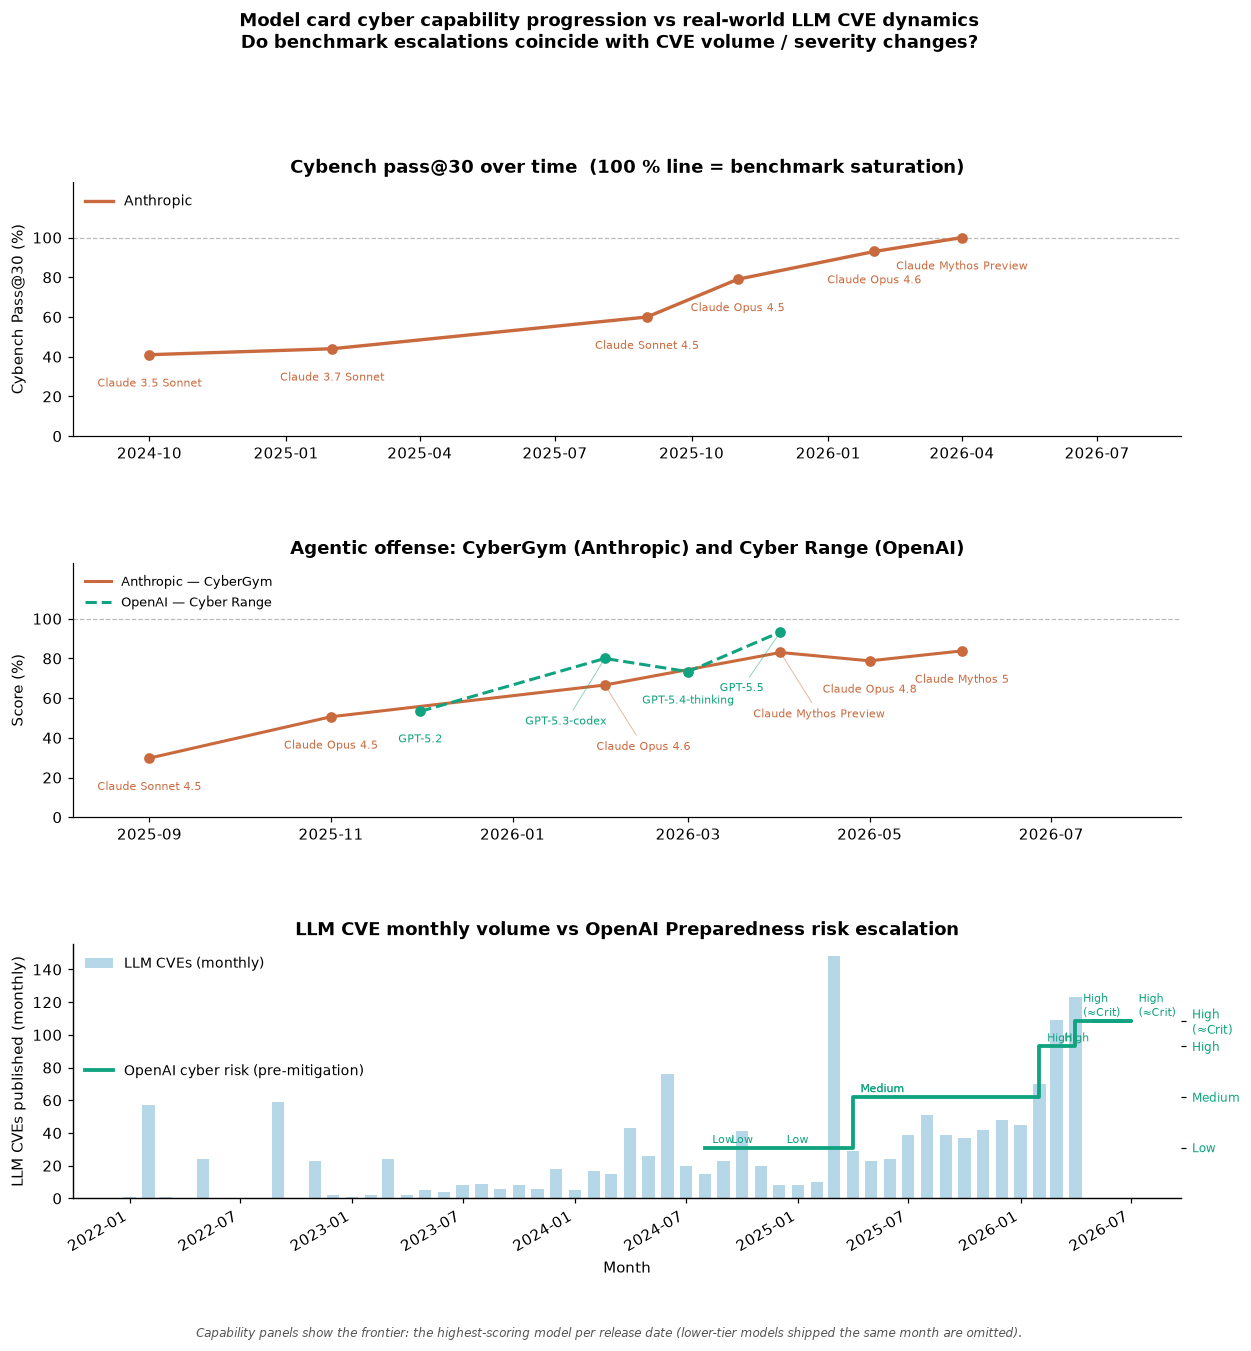

Saved: capability_vs_cve_progression.png


In [51]:
import matplotlib.dates as mdates  # safe re-import

VENDOR_COLORS_LOCAL = {"OpenAI": "#10a37f", "Anthropic": "#c96a3e", "Google": "#4285F4"}

# ── Manual per-label nudges ───────────────────────────────────────────────
# To move ONE label, add its exact model name here with an offset of
#   (days_right, score_up)  — e.g. (+20, -5) shifts it 20 days right, 5 pts down.
# Leave empty to use the automatic placement below.
LABEL_NUDGE = {
    # "Claude Opus 4.7":      (0, -3),
     "Claude Mythos Preview": (0, 0),
}

def _place(ax, it, tx, ty, ha, va, fs, leader):
    ddays, dval = LABEL_NUDGE.get(it["text"], (0, 0))
    ax.annotate(it["text"], xy=(it["x"], it["y"]),
                xytext=(tx + pd.Timedelta(days=ddays), ty + dval),
                textcoords="data", ha=ha, va=va, fontsize=fs, color=it["color"],
                arrowprops=(dict(arrowstyle="-", color=it["color"], lw=0.6, alpha=0.5)
                            if leader else None))

def _label_points(ax, items, fs=7.5,
                  drop=0.09,          # how far below a lone point its label sits (fraction of y-range)
                  right_gap_days=16,  # horizontal distance of a right-stacked label from its point
                  right_step=0.10,    # vertical spacing between right-stacked labels (fraction of y-range)
                  fan_days=26,        # horizontal spread of a fanned interior cluster
                  fan_drop=0.12,      # first fanned label's drop below the cluster (fraction of y-range)
                  fan_step=0.10):     # extra drop per stacked fanned label (fraction of y-range)
    """Label points with full names, keeping labels off the lines.
    Isolated points → plain label below; the final same-date cluster → stacked
    to the right with leaders; interior same-date clusters → fanned below with
    leaders. Tune the keyword args (or LABEL_NUDGE for one label) to taste."""
    if not items:
        return
    items = sorted(items, key=lambda d: d["x"])
    clusters = [[items[0]]]
    for it in items[1:]:
        if (it["x"] - clusters[-1][-1]["x"]).days <= 25:   # "same date" window
            clusters[-1].append(it)
        else:
            clusters.append([it])
    ylo, yhi = ax.get_ylim(); span = yhi - ylo
    last_x = max(it["x"] for it in items)
    for cl in clusters:
        if len(cl) == 1:                                   # isolated point
            it = cl[0]
            _place(ax, it, it["x"], it["y"] - span * drop, "center", "top", fs, leader=False)
        elif any(it["x"] == last_x for it in cl):          # terminal cluster → stack right
            cl = sorted(cl, key=lambda d: -d["y"])
            start = min(max(d["y"] for d in cl), yhi - span * 0.14)
            lx = cl[0]["x"] + pd.Timedelta(days=right_gap_days)
            for k, it in enumerate(cl):
                _place(ax, it, lx, start - k * span * right_step, "left", "center", fs, leader=True)
        else:                                              # interior cluster → fan below
            cl = sorted(cl, key=lambda d: -d["y"])
            n = len(cl); base = min(d["y"] for d in cl)
            for k, it in enumerate(cl):
                lx = it["x"] + pd.Timedelta(days=(k - (n - 1) / 2) * fan_days)
                _place(ax, it, lx, base - span * (fan_drop + fan_step * k), "center", "top", fs, leader=True)

def _pad_xlim(ax, left=0.04, right=0.20):
    lo, hi = ax.get_xlim(); span = hi - lo
    ax.set_xlim(lo - span * left, hi + span * right)

fig, axes = plt.subplots(3, 1, figsize=(13, 12), gridspec_kw={"hspace": 0.5})

# ── Panel 1: Cybench Pass@30 progression ──────────────────────────────────
ax1 = axes[0]
cb = (bench[bench["metric"] == "Cybench Pass@30 %"]
      .drop_duplicates(["model", "vendor", "release_date"])
      .sort_values("release_date"))
# Frontier envelope: keep only the highest-scoring model per release date, so
# each line tracks demonstrated capability instead of mixing model tiers. A
# smaller model shipped the same month (e.g. Sonnet 5 under Mythos 5, Opus 4.7
# under Mythos Preview) no longer creates a downward zig-zag — dominated points
# are omitted by rule, not by hand.
cb = cb.loc[cb.groupby(["vendor", "release_date"])["value"].idxmax()].sort_values("release_date")
items1 = []
for vendor, grp in cb.groupby("vendor"):
    color = VENDOR_COLORS_LOCAL.get(vendor, "#888")
    grp = grp.sort_values("release_date")
    ax1.plot(grp["release_date"], grp["value"], "o", color=color, zorder=5)
    ax1.plot(grp["release_date"], grp["value"], "-", color=color, lw=2.2,
             label=vendor, zorder=5)
    items1 += [{"x": r["release_date"], "y": r["value"], "text": r["model"], "color": color}
               for _, r in grp.iterrows()]
ax1.set_ylim(0, 128)
ax1.set_yticks([0, 20, 40, 60, 80, 100])   # headroom to 128 for the legend, but ticks stop at 100
ax1.axhline(100, color="#bbb", lw=0.8, ls="--", zorder=1)
_label_points(ax1, items1, fs=7.5)
_pad_xlim(ax1)
ax1.set_ylabel("Cybench Pass@30 (%)")
ax1.set_title("Cybench pass@30 over time  (100 % line = benchmark saturation)")
ax1.legend(frameon=False, fontsize=9, loc="upper left")   # sits above the 100 % line
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# ── Panel 2: CyberGym (Anthropic) + Cyber Range (OpenAI) ─────────────────
ax2 = axes[1]
fams = bench[bench["family"].isin(["Agentic Offense (CyberGym)", "Cyber Range"])]
fams = fams.drop_duplicates(["model", "metric", "release_date"])
# Frontier envelope per (vendor, family): best-scoring model per release date.
fams = fams.loc[fams.groupby(["vendor", "family", "release_date"])["value"].idxmax()].sort_values("release_date")
items2 = []
for (vendor, family), grp in fams.groupby(["vendor", "family"]):
    grp = grp.sort_values("release_date")
    color = VENDOR_COLORS_LOCAL.get(vendor, "#888")
    ls = "-" if "CyberGym" in family else "--"
    label = f"{vendor} — {'CyberGym' if 'CyberGym' in family else 'Cyber Range'}"
    ax2.plot(grp["release_date"], grp["value"], "o", color=color, zorder=5)
    ax2.plot(grp["release_date"], grp["value"], color=color, lw=2, ls=ls, label=label)
    items2 += [{"x": r["release_date"], "y": r["value"], "text": r["model"], "color": color}
               for _, r in grp.iterrows()]
ax2.set_ylim(0, 128)
ax2.set_yticks([0, 20, 40, 60, 80, 100])
ax2.axhline(100, color="#bbb", lw=0.8, ls="--", zorder=1)
_label_points(ax2, items2, fs=7)
_pad_xlim(ax2)
ax2.set_ylabel("Score (%)")
ax2.set_title("Agentic offense: CyberGym (Anthropic) and Cyber Range (OpenAI)")
ax2.legend(frameon=False, fontsize=8.5, loc="upper left")  # sits above the 100 % line
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# ── Panel 3: LLM CVE monthly count + OpenAI risk level staircase ─────────
ax3 = axes[2]
ax3b = ax3.twinx()
monthly_vol = df_full.groupby("month").size().reset_index(name="count")
ax3.bar(monthly_vol["month"], monthly_vol["count"], width=20,
        color="#9ecae1", alpha=0.75, label="LLM CVEs (monthly)")
ax3.set_ylabel("LLM CVEs published (monthly)")

risk = (bench[bench["metric"] == "Cyber Risk Level"]
        .drop_duplicates(["model", "release_date"])
        .query("vendor == 'OpenAI'")
        .sort_values("release_date"))
if not risk.empty:
    end = pd.Timestamp("2026-05-01")
    step_x = list(risk["release_date"]) + [end]
    step_y = list(risk["value"]) + [risk["value"].iloc[-1]]
    ax3b.step(step_x, step_y, where="post", color="#10a37f", lw=2.5,
              label="OpenAI cyber risk (pre-mitigation)")
    for _, r in risk.iterrows():
        lbl = {1: "Low", 2: "Medium", 3: "High", 3.5: "High\n(≈Crit)"}.get(r["value"], "")
        ax3b.annotate(lbl, (r["release_date"], r["value"]),
                      xytext=(5, 3), textcoords="offset points",
                      fontsize=7.5, color="#10a37f")
    ax3b.set_yticks([1, 2, 3, 3.5])
    ax3b.set_yticklabels(["Low", "Medium", "High", "High\n(≈Crit)"],
                          fontsize=8, color="#10a37f")
    ax3b.set_ylim(0, 5)
    ax3b.tick_params(axis="y", labelcolor="#10a37f")
    ax3b.spines["top"].set_visible(False)
    ax3b.legend(loc="center left", frameon=False, fontsize=9)

ax3.set_xlabel("Month")
ax3.set_title("LLM CVE monthly volume vs OpenAI Preparedness risk escalation")
ax3.legend(loc="upper left", frameon=False, fontsize=9)
ax3.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax3.get_xticklabels(), rotation=30, ha="right")
ax3.spines["top"].set_visible(False)

plt.suptitle(
    "Model card cyber capability progression vs real-world LLM CVE dynamics\n"
    "Do benchmark escalations coincide with CVE volume / severity changes?",
    fontsize=11.5, fontweight="bold", y=1.01)
fig.text(0.5, 0.005,
         "Capability panels show the frontier: the highest-scoring model per release date "
         "(lower-tier models shipped the same month are omitted).",
         ha="center", fontsize=8, style="italic", color="#555")
plt.savefig("capability_vs_cve_progression.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: capability_vs_cve_progression.png")
